# Two-Dim Gaussian Interpolation
### Sub-steps:
**1)** *Build the grid time x wavelength using flux calibrated spectra, UV photometry and optical photometry (only where spectrophotometry is sparse)*

**2)** *Model the data using 2dim GPs and determine the 2dim interpolated surface*

**3)** *Predict UV extension for your sparse spectrophotometry*

**4)** *Predict additional spectra at the phases where spectrophotometry is sparse (FROM sparse spectrophotometry ---> TO spectrophotometry with high and homogeneous cadence)*

**This copy (`*_ryanv2`) writes** `Outputs/<SN>/twodim_ryanv2/...`, **runs** `GP2dim_utils_newlog_rjf.run_2DGP_GRID_rjf` (collaborator kernel + jitter + $\mu$ post-processing), and leaves the original `twodim/` notebooks untouched.

Tune `pipeline_config.GP_RJF_KWARGS` / `GP_RJF_PLOT_RAW_AND_PROCESSED`; see `Codes/docs/PLAN_GP_RJF_integration.md`.

### Log-space variant (this notebook)

**What the pipeline does (same logic as `6_TwoDim_UVExtend_Extrapolate_KN_original.ipynb`):**

1. **Build a 2D grid** of spectrophotometry: each mangled spectrum is placed on a common wavelength axis; columns are spectral epochs. UV gaps are filled using synthetic photometry from filter integrals (same UV-extension idea as the linear notebook).
2. **Overlay the GP light-curve fit** (`fitted_phot_logspace_*.dat`) on that grid on sparse columns, including extrapolated log-phase columns (same gap-filling cadence logic as original, but in `Log_Phase`).
3. **`transform2LOG_reshape`** (in `GP2dim_utils_newlog.py` by default) converts **log10(flux)** from the files to **ln(flux)** (the same quantity the original code modeled after `np.log(linear_flux)`), subtracts a minimum and divides by a median scale, and normalizes **log10(λ)** and **log10(phase days)** for the GP (min–max by default, or training z-scores if you import `GP2dim_utils_newlog_zscore` via `USE_TWO_D_GP_ZSCORE_COORDS`).
4. **2D GP** (Matern 3/2) interpolates in that scaled space, optionally with a prior surface from `Inputs/2DIM_priors/`.
5. **Transform back** with `exp(mu*scale + offset)` to **linear flux** for plots and output files (same as original).
6. **Save** extended spectra: stitched UV/IR from the GP with observed spectrum where available.

**Edits in this notebook (vs your earlier newlog draft):** `get_spec_mjd` is a proper class method (it was accidentally un-indented). UV rows now use the same **linear** flux residual as the original notebook, then store **log10** of that residual so the grid stays consistent with the rest of the log pipeline.


**Companion module:** `GP2dim_utils_newlog.py` implements the same GP steps as `GP2dim_utils_original.py`, adapted so inputs are log10 flux on log10(wavelength) × log10(phase) axes; see that file for `transform2LOG_reshape`, `setPRIOR`, `run_2DGP_GRID`, `transform_back_andPlot`, and `save_plots_files`.

**Linear-flux 2D GP (optional):** In `pipeline_config.py`, set `USE_TWO_D_GP_LINEAR_FLUX = True` so the paths cell imports `GP2dim_utils_newlog_linear_flux` (same log10(λ) and log10(phase) axes; the GP fits affine-scaled linear flux). If you set a numeric `GP_WHITE_NOISE_LINEAR`, it overrides `GP_WHITE_NOISE` for that mode only.

**Z-score GP coordinates (optional, ln-flux path):** Set `USE_TWO_D_GP_ZSCORE_COORDS = True` (and leave `USE_TWO_D_GP_LINEAR_FLUX = False`) so the paths cell imports `GP2dim_utils_newlog_zscore`: training coordinates are per-axis mean/std standardized instead of min–max. Flux scaling in `transform2LOG_reshape` matches `GP2dim_utils_newlog`.

**Share GP inputs with a collaborator:** Set `pipeline_config.GP_EXPORT_MINIMAL = True` (or `spec_class.gp_export_minimal = True`) before running the `run_2DGP_GRID` cell. After the GP finishes, find `gp_minimal_bundle.npz` and `gp_minimal_bundle_meta.json` under `save_plot_path` / `gp_minimal_export` (see `Codes/GP2D_COLLABORATOR_README.md`).

**Mangled spectrum files (log mangle notebook):** `wls` is **linear Å**; `flux` / `fluxerr` are **log10**. Cell 8 matches that format and builds the GP grid on **log10(λ)**.


In [1]:
import os
#COCO_PATH=os.environ['COCO_PATH']
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
DATALC_PATH = COCO_PATH+"/Inputs/Photometry/4_LCs_late_extrapolated/"
DATASPEC_PATH = COCO_PATH+"/Inputs/Spectroscopy/"

DATAINFO_PATH= COCO_PATH+"Inputs/SNe_Info/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/"

PRIORs_PATH = COCO_PATH+'Inputs/2DIM_priors'
OUTPUT_DIR = COCO_PATH+"Outputs/"

import sys
sys.path.insert(0, COCO_PATH+'what_the_flux/')
sys.path.insert(0, COCO_PATH+'/Codes/')
import what_the_flux as wtf
import pipeline_config as _pconf
if _pconf.USE_TWO_D_GP_LINEAR_FLUX:
    import GP2dim_utils_newlog_linear_flux as GP2dim
elif getattr(_pconf, "USE_TWO_D_GP_ZSCORE_COORDS", False):
    import GP2dim_utils_newlog_zscore as GP2dim
else:
    import GP2dim_utils_newlog as GP2dim


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import pandas as pd
from collections import OrderedDict

from numpy.linalg import inv
from scipy import misc

import math

import scipy
from scipy import interpolate
from scipy import integrate
import scipy.optimize as opt
from scipy.optimize import minimize
from itertools import cycle

import george
from george.kernels import Matern32Kernel
%matplotlib inline

/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_96836/437759662.py:9: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


In [3]:
CSP_SNe = ['SN2004fe', 'SN2005bf', 'SN2006V', 'SN2007C', 'SN2007Y',
           'SN2009bb',  'SN2008aq', 'SN2006T', 'SN2004gq', 'SN2004gt',
           'SN2004gv','SN2006ep', 'SN2008fq', 'SN2006aa']
pre_bump = ['SN2011dh','SN1993J','SN2008D','SN2011fu','SN2006aj','SN1987A','SN2013df']

In [4]:
color_dict = {'Bessell_U': 'blue', 'Bessell_B': 'royalblue','Bessell_V':  'limegreen',
              'Bessell_R':  'red', 'Bessell_I':  'mediumvioletred',
              'sdss_g':'darkgreen','ptf_g':'darkgreen', "sdss_g'":'darkgreen','sdss_i':'indianred',
              "sdss_i'":'indianred','sdss_r': 'darkred', "sdss_r'":'darkred','sdss_z':'sienna', "sdss_z'":'sienna',
              'sdss_u': 'darkblue', "sdss_u'": 'darkblue', 'Y':'salmon','H':'darkred', 'J':  'k',
              'Ks':  'brown','K':  'brown', 'swift_UVW1':'indigo', 'swift_UVW2':'darkblue',
               'swift_UVM2':'darkmagenta','swift_U':'plum','swift_V':'teal','swift_B':'powderblue'}

mark_dict = {'Bessell_U': 'o','Bessell_B': 'o', 'Bessell_V':'o', 'Bessell_R':'o', 'Bessell_I': 'o', 
             'sdss_g':'s','ptf_g':'s', "sdss_g'":'s', 'sdss_i':'s', "sdss_i'":'s',
                'sdss_r':'s', "sdss_r'":'s', 'sdss_z':'s', "sdss_z'":'s', 'sdss_u': 's', "sdss_u'": 's',
                'Y':  'o','H':  'o', 'J':  'o', 'Ks':  'o','K':  'o',
                'swift_UVW1':'D', 'swift_UVW2':'D', 'swift_UVM2':'D', 'swift_U':'D',
                'swift_V':'D', 'swift_B':'D'}

CSP_SNe = ['SN2004fe', 'SN2005bf', 'SN2006V', 'SN2007C', 'SN2007Y',
           'SN2009bb',  'SN2008aq', 'SN2006T', 'SN2004gq', 'SN2004gt',
           'SN2004gv','SN2006ep', 'SN2008fq', 'SN2006aa']

#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y']
#exclude_filt = ['KS']

convert2mjd = (lambda x: float(x.replace('_REmangled_spec.txt','')\
                               .replace('_REmangled_spec_FL.txt','')\
                               .replace('_mangled_spec.txt','')))

In [5]:
color_dict = {
    # Existing matches from your example
    'Swope_i': 'indianred',
    'FourStar_H': 'darkred',
    'FourStar_J': 'black',
    'DECam_i': 'orangered',
    'DECam_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FourStar_Ks': 'brown',
    'UVOT_U': 'teal',
    'Skymapper_i': 'slateblue',
    'Sinistro_g': 'darkgreen',
    'Sinistro_r': 'crimson',
    'Skymapper_r': 'deeppink',
    'Skymapper_g': 'forestgreen',
    'EFOSC2_V': 'limegreen',
    'Sinistro_i': 'firebrick',
    'DECam_r': 'darkorange',
    'DECam_g': 'mediumspringgreen',
    'DECam_u': 'navy',
    'Swope_V': 'green',
    'FourStar_J1': 'dimgray',
    'Swope_B': 'royalblue',
    'Swope_r': 'red',
    'Swope_g': 'darkseagreen',
    'EFOSC2_U': 'blue',
    'Sinistro_V': 'mediumaquamarine',
    'Sinistro_z': 'sienna',
    'IMACS_r': 'darkred',
    'LRIS_I': 'mediumvioletred',
    'SOFI_H': 'firebrick',
    'SOFI_Ks': 'saddlebrown',

    # New assignments (color-coded by band)
    'VISTA_Ks': 'saddlebrown',
    'VISTA_J': 'dimgray',
    'VISTA_Y': 'salmon',
    'FLAMINGOS-2_Ks': 'sienna',
    'UVOT_M2': 'darkviolet',
    'UVOT_W1': 'purple',
    'UVOT_W2': 'indigo',
    'HSC_z': 'darkslategray',
    'GFC_i': 'firebrick',
    'GFC_y': 'goldenrod',
    'GFC_z': 'maroon',
    'GFC_r': 'tomato',
    'SIRIUS_H': 'darkred',
    'SIRIUS_J': 'black',
    'SIRIUS_Ks': 'brown',
    'T80Cam_g': 'seagreen',
    'GROND_H': 'maroon',
    'GROND_J': 'dimgray',
    'GROND_K': 'saddlebrown',
    'GROND_g': 'mediumseagreen',
    'GROND_i': 'orangered',
    'GROND_r': 'crimson',
    'GROND_z': 'darkslategray',
    'DECam_Y': 'goldenrod',
    'FLAMINGOS-2_H': 'firebrick',
    'IMACS_i': 'orangered',
    'FLAMINGOS-2_J': 'black',
    'UVOT_B': 'dodgerblue',
    'GMOS_g': 'green',
    'GMOS_i': 'indianred',
    'GMOS_r': 'red',
    'GMOS_z': 'darkslategray',
    'FORS2_R': 'crimson',
    'VIMOS_z': 'maroon',
    'FORS2_I': 'mediumvioletred',
    'FORS2_B': 'blue',
    'FORS2_V': 'limegreen',
    'ANDICAM_K': 'brown',
    'MOIRCS_Ks': 'sienna',
    'HAWKI_Ks': 'brown'
}

exclude_filt = []
#exclude_filt = ['H', 'J', 'K', 'Ks','KS', 'Y', 'FourStar_H', 'FourStar_J', 'FourStar_Ks', 'FourStar_J1',
#                'RetroCam_Y', 'RetroCam_H', 'RetroCam_J', 'SOFI_H', 'SOFI_Ks']

mark_dict = {
    # Swope (Circle)
    'Swope_i': 'o',
    'Swope_V': 'o',
    'Swope_B': 'o',
    'Swope_r': 'o',
    'Swope_g': 'o',

    # FourStar (Circle)
    'FourStar_H': 'o',
    'FourStar_J': 'o',
    'FourStar_Ks': 'o',
    'FourStar_J1': 'o',
    'FourStar_Ks': 'o',

    # VISTA (Circle - keeping consistent with other IR survey survey data)
    'VISTA_Ks': 'o',
    'VISTA_J': 'o',
    'VISTA_Y': 'o',

    # SOFI (Circle)
    'SOFI_H': 'o',
    'SOFI_Ks': 'o',

    # ANDICAM (Circle)
    'ANDICAM_K': 'o',

    # DECam (Triangle Up)
    'DECam_i': '^',
    'DECam_z': '^',
    'DECam_Y': '^',
    'DECam_r': '^',
    'DECam_g': '^',
    'DECam_u': '^',

    # HSC (Triangle Right - distinct from DECam but similar large imager)
    'HSC_z': '>',

    # MOIRCS (Triangle Right - Subaru)
    'MOIRCS_Ks': '>',

    # FLAMINGOS-2 (Triangle Down - Gemini IR)
    'FLAMINGOS-2_Ks': 'v',
    'FLAMINGOS-2_H': 'v',
    'FLAMINGOS-2_J': 'v',

    # GMOS (Triangle Left - Gemini Optical)
    'GMOS_g': '<',
    'GMOS_i': '<',
    'GMOS_r': '<',
    'GMOS_z': '<',

    # FORS2 (Triangle Left - VLT)
    'FORS2_R': '<',
    'FORS2_I': '<',
    'FORS2_B': '<',
    'FORS2_V': '<',

    # VIMOS (Triangle Left - VLT)
    'VIMOS_z': '<',

    # HAWKI (Triangle Left - VLT)
    'HAWKI_Ks': '<',

    # UVOT (Cross)
    'UVOT_M2': 'X',
    'UVOT_W1': 'X',
    'UVOT_U': 'X',
    'UVOT_W2': 'X',
    'UVOT_B': 'X',

    # GFC / Pan-STARRS (Pentagon)
    'GFC_i': 'p',
    'GFC_y': 'p',
    'GFC_z': 'p',
    'GFC_r': 'p',

    # Skymapper (Plus Filled)
    'Skymapper_i': 'P',
    'Skymapper_r': 'P',
    'Skymapper_g': 'P',

    # Sinistro (Square)
    'Sinistro_g': 's',
    'Sinistro_r': 's',
    'Sinistro_i': 's',
    'Sinistro_V': 's',
    'Sinistro_z': 's',

    # IMACS (Square)
    'IMACS_i': 's',
    'IMACS_r': 's',

    # SIRIUS (Diamond - grouped with other medium aperture IR like SOFI/RetroCam? or Diamond like EFOSC2)
    'SIRIUS_H': 'D',
    'SIRIUS_J': 'D',
    'SIRIUS_Ks': 'D',

    # EFOSC2 (Diamond)
    'EFOSC2_V': 'D',
    'EFOSC2_U': 'D',

    # LRIS (Diamond)
    'LRIS_I': 'D',

    # T80Cam (Star - distinct small survey)
    'T80Cam_g': '*',

    # GROND (Hexagon - multi-channel instrument)
    'GROND_H': 'h',
    'GROND_J': 'h',
    'GROND_K': 'h',
    'GROND_g': 'h',
    'GROND_i': 'h',
    'GROND_r': 'h',
    'GROND_z': 'h'
}

In [6]:
def calc_lam_eff(wls, transmission):
    return (integrate.trapezoid(transmission*wls, wls)/\
            integrate.trapezoid(transmission, wls))

In [7]:
# Requires earlier cell: paths (OUTPUT_DIR, …), numpy/pandas, scipy, matplotlib, ``convert2mjd``, ``CSP_SNe``.
import os

import numpy as np

# Uses global ``GP2dim`` from the paths cell (``GP2dim_utils_newlog`` or ``GP2dim_utils_newlog_linear_flux``).

class FullMangledSeries_Class():
    """Class to load and mangle a single spectrum:
    """

    @staticmethod
    def _wls_are_linear_angstrom(wls_arr):
        """Delegates to ``GP2dim.mangled_wls_max_is_linear_angstrom`` (paths cell imports newlog or linear_flux)."""
        return GP2dim.mangled_wls_max_is_linear_angstrom(wls_arr)

    @staticmethod
    def _spec_wls_linear(spec_rec):
        return GP2dim.mangled_wls_linear_angstrom(spec_rec)

    @staticmethod
    def _log10_flux_to_linear(flux_arr):
        return GP2dim.mangled_flux_linear_from_log10(flux_arr)
    
    def __init__(self, snname, t0_fix, type_=None, spec_file=None, 
                    mode = 'extend_spectra' , verbose=False, DELTA=50.):
        """
        mode: 'extend_spectra'  or 'extrapolate_spectra' 
        """
        ## Initialise the class variables            
        self.snname = snname
        self.SNtype = type_
        self.mode = mode
        
        # --- NEW: Fetch explosion date for log conversions ---
        self.t0_fix = t0_fix
        # -----------------------------------------------------

        self.get_mangledspec_list()
        self.DELTA = DELTA
        self.verbose = verbose
        self.create_extended_spec_folder() 
        
        # --- CHANGED: Point to the new logspace file ---
        self.path_fit_phot = OUTPUT_DIR+'/%s/fitted_phot_logspace_%s.dat'%(snname,snname)
        # -----------------------------------------------
        # Default: no dex-span chop. Setting this to 2 caps range to 2 dex in log10(phase) from the
        # *minimum* grid time (~0.1 d -> ~10 d max) — not 200 calendar days. KN needs None for ~25+ d.
        self.extrapolate_log_phase_span_dex = None
        # --- Log10(phase-day) greeding for LC on extrap times only (replaces m % 3 on mjds_grid index) ---
        # All below are in **dex** in log10(phase in days), not linear days.
        self.extrap_phot_cadence_dex_early = 0.04
        # Smaller = more LC at late phase (e.g. log10>1); larger = sparser; tune.
        self.extrap_phot_cadence_dex_late = 0.10
        self.extrap_phot_cadence_log_phase_split = 0.0
        self.extrap_phot_cadence_transition_halfwidth_dex = 0.15
        # Log-spaced early extrapolation: dex span from gmin (replaces 0.1 only).
        self.extrap_phot_early_span_dex = 1.5
        # fill_gaps: sub-threshold linear gap but large log span (args passed into GP2dim)
        self.extrapolate_tiny_linear_gap_min_log_span_dex = 0.15
        self.extrapolate_tiny_linear_gap_max_interior = 200

    def _extrap_phot_cadence_min_sep_dex(self, log_t):
        """Min separation in log10(phase days) for greedy LC placement; early vs late linear blend."""
        e = float(getattr(self, "extrap_phot_cadence_dex_early", 0.04))
        l_ = float(getattr(self, "extrap_phot_cadence_dex_late", 0.12))
        s = float(getattr(self, "extrap_phot_cadence_log_phase_split", 0.0))
        h = float(getattr(self, "extrap_phot_cadence_transition_halfwidth_dex", 0.15))
        t = float(log_t)
        lo_b, hi_b = s - h, s + h
        if t <= lo_b:
            return e
        if t >= hi_b:
            return l_
        span = hi_b - lo_b
        u = 0.0 if span <= 0.0 else (t - lo_b) / span
        u = min(1.0, max(0.0, u))
        return (1.0 - u) * e + u * l_

    def _select_extrap_phot_times(self, mjds_extention):
        """Subsample mjds_extention in log10(phase): dense early, sparser late; always keep first+last.

        This acts only on *extrapolation* times, not on spectrum-column indices in mjds_grid, so
        sparsity is tied to physical phase, not a raw column index m.
        """
        arr = np.sort(np.unique(np.round(np.asarray(mjds_extention, dtype=float), 10)))
        if arr.size == 0:
            return arr
        out = [float(arr[0])]
        last = float(arr[0])
        for t in arr[1:]:
            t = float(t)
            if t - last >= self._extrap_phot_cadence_min_sep_dex(t):
                out.append(t)
                last = t
        last_ex = float(arr[-1])
        if not any(np.isclose(out, last_ex, rtol=0.0, atol=1e-9)):
            out.append(last_ex)
        return np.sort(np.unique(np.round(out, 10)))

    @staticmethod
    def _extrap_time_in_allowed(t, allowed_arr):
        if allowed_arr is None or len(allowed_arr) == 0:
            return False
        return bool(np.any(np.isclose(allowed_arr, float(t), rtol=0.0, atol=1e-9)))

    def get_mangledspec_list(self, extend_spectra = True, extrapolate_spectra=False, verbose=False):
        if self.mode == 'extend_spectra':
            mypath = OUTPUT_DIR+'/%s/mangled_spectra'%self.snname
            onlyfiles = [f for f in os.listdir(mypath) \
                     if os.path.isfile(os.path.join(mypath, f))&('mangled_spec' in f)&('.txt' in f)]
            self.mangledspec_list = onlyfiles
            self.mangled_file_path = mypath+'/'
        elif self.mode == 'extrapolate_spectra':
            mypath = OUTPUT_DIR+'/%s/mangled_spectra'%self.snname
            onlyfiles = [f for f in os.listdir(mypath) \
#                         if os.path.isfile(os.path.join(mypath, f))&('REmangled_spec' in f)&('.txt' in f)&('_FL' not in f)]
                         if os.path.isfile(os.path.join(mypath, f))&('mangled_spec' in f)&('.txt' in f)]
            self.mangledspec_list = onlyfiles
            self.mangled_file_path = mypath+'/'
        return onlyfiles
    
    def load_mangledfile(self, file):
        mangled_spec = np.genfromtxt(self.mangled_file_path+file, dtype=None,\
                                     encoding="utf-8", names=['wls', 'flux', 'fluxerr', 'mang_mask'])
        return mangled_spec

          
    def load_manglingfile(self, mjd):
        #if not hasattr(self, "results_mainpath"):
        #    self.check_mangling_file()
        mangling_file = OUTPUT_DIR+'/%s/fitted_phot4mangling_%s.dat'%(self.snname,self.snname)
        if not os.path.isfile(mangling_file):
            raise Exception("I need the file with fitted photometry in order to mangle a spectrum")
        else:
            phot4mangling = pd.read_csv(mangling_file, sep='\t')
            #print (phot4mangling)#self.phot4mangling = 
            specmjd= mjd#float(self.spec_file.replace('mangled_spec_','').replace('.txt',''))
# --- CHANGED: Added rtol=0.0 to prevent numpy from scaling the tolerance ---
            self.phot4mangling = phot4mangling[phot4mangling['spec_mjd'] == mjd]
            #print("Searching for MJD:", specmjd)
            #print("Available MJDs:", phot4mangling['spec_mjd'].values)
            #print("Closest match:", phot4mangling['spec_mjd'].iloc[np.argmin(np.abs(phot4mangling['spec_mjd'] - specmjd))])
            if len(self.phot4mangling)<1:
                raise Exception(""" ### ERROR: 
I looked in the file with the PHOTOMETRY for MANGLING 
(i.e. fitted_phot4mangling_SNNAME.dat).
I was loading the photometry to mangle/extend the spectrum you are currently loading
in the GRID. I found NO photometry for it... Maybe you should re run GP fit or check your list of spec.""")

            elif len(self.phot4mangling)>1:
                raise Exception(""" ###  TRICKY ERROR: 
I looked in the file with the PHOTOMETRY for MANGLING 
(i.e. fitted_phot4mangling_SNNAME.dat).
I was loading the photometry to mangle/extend the spectrum you are currently loading
in the GRID. I found two spectra at the exact same MJD and this is problem when
I try to build the TIMExWLS grid with this.
Check the phot4mangling.txt file and check if you're MJDs are correct and 
have the right decimals.""")
# --- CHANGED: Look for the log flux columns ---
            self.avail_filters = [col.replace('_fit_log_flux','') for col in phot4mangling.columns\
                                  if col.endswith('_fit_log_flux')]       
    
    def create_extended_spec_folder(self):
        import pipeline_config as _pconf
        save_plot_path = _pconf.twodim_ryanv2_extended_base(OUTPUT_DIR, self.snname, self.mode)
        if not os.path.exists(save_plot_path):
            os.makedirs(save_plot_path)
        else:
            os.system('rm -rf %s'%save_plot_path)
            os.makedirs(save_plot_path)

        self.save_plot_path = save_plot_path
        self.save_dual_products = (not _pconf.USE_LEGACY_TWODIM_LAYOUT)
        self.pipeline_wl_min_a = _pconf.PIPELINE_WL_MIN_A
        self.pipeline_wl_max_a = _pconf.PIPELINE_WL_MAX_A
        _gwn_lin = getattr(_pconf, "GP_WHITE_NOISE_LINEAR", None)
        if _pconf.USE_TWO_D_GP_LINEAR_FLUX and _gwn_lin is not None:
            self.gp_white_noise = float(_gwn_lin)
        else:
            self.gp_white_noise = float(_pconf.GP_WHITE_NOISE)
        # Optional: densify 2D GP prediction phases in log10(days) between current column min/max (default off).
        self.gp_predict_dense_log_phase = bool(_pconf.GP_PREDICT_DENSE_LOG_PHASE)
        self.gp_predict_dense_log_phase_n = int(_pconf.GP_PREDICT_DENSE_LOG_PHASE_N)
        self.gp_2d_anchor_t0 = bool(_pconf.GP_2D_ANCHOR_T0)
        self.gp_2d_t0_anchor_log_phase = float(_pconf.GP_2D_T0_ANCHOR_LOG_PHASE)
        self.gp_2d_t0_anchor_log10_flux_cap = float(_pconf.GP_2D_T0_ANCHOR_LOG10_FLUX_CAP)
        self.gp_2d_t0_anchor_log10_flux_err = float(_pconf.GP_2D_T0_ANCHOR_LOG10_FLUX_ERR)

    def running_mean_std(self, x, y, delta_fix=500.):
        #x = xnan[~np.isnan(ynan)]
        #y = ynan[~np.isnan(ynan)]
        
        total_bins = int((x.max()-x.min())/delta_fix)
        bins = np.linspace(x.min(),x.max(), total_bins)
        try:
            delta = bins[1]-bins[0]
            idx  = np.digitize(x,bins)
            running_median_x = np.array([np.mean(x[idx==k]) for k in np.arange(1,total_bins,1)])
            running_mean = np.array([np.mean(y[idx==k]) for k in np.arange(1,total_bins,1)])
            running_std = np.array([np.std(y[idx==k]) for k in np.arange(1,total_bins,1)])
        except IndexError:
            running_median_x = np.array([np.mean(x)])
            running_mean = np.array([np.mean(y)])
            running_std = np.array([np.std(y)])
            
        clean_running_median_x = np.copy(running_median_x)
        clean_running_median_x[running_mean<0.] = np.nan
        clean_running_mean = np.copy(running_mean)
        clean_running_mean[running_mean<0.] = np.nan
        clean_running_std = np.copy(running_std)
        clean_running_std[running_mean<0.] = np.nan
        
        return clean_running_median_x, clean_running_mean, clean_running_std

    def get_filt_transmission(self, filter_name):
        
        if 'swift' in filter_name:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Swift/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        #else:
            #filt_transm = np.genfromtxt(FILTER_PATH+'/GeneralFilters/%s.dat'%filter_name,\
                                                 #dtype=None, encoding="utf-8", names=['wls', 'flux'])
        else:
            filt_transm = np.genfromtxt(FILTER_PATH+'/GeneralFilters/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        wls = filt_transm['wls']
        transmission = filt_transm['flux']
        return wls, transmission

    def lam_eff(self, filter_name): 
        wls, transmission = self.get_filt_transmission(filter_name)
        linear_eff = (integrate.trapezoid(transmission*wls, wls)/\
            integrate.trapezoid(transmission, wls))
        
        # --- CHANGED: Convert the final answer to log-space (rounded index key) ---
        return float(np.round(np.log10(linear_eff), 8))

    def load_phot_for_extention(self, file, anchor = False):
        data_spec_mangled = self.load_mangledfile(file)
        
        # 1. Get the linear MJD from the filename
        raw_mjd = convert2mjd(file)
        
        # 2. Pass the LINEAR MJD to the lookup function to avoid log-collisions
        self.load_manglingfile(raw_mjd)
        
        # 3. Now calculate the Log_Phase for the rest of the math
        phase = raw_mjd - self.t0_fix
        if phase <= 0: phase = 1e-5
        mjd = np.log10(phase)
        
        all_fitted_phot_list=[]
        # ... (rest of the function stays exactly the same)
        fitted_phot_list=[]
        fitted_photerr_list=[]
        wls_eff=[]
        filters4extention=[]
        for filt in self.avail_filters:
            lam_eff_value = self.lam_eff(filt)
# --- CHANGED: Read the log flux strings ---
            fitted_phot = self.phot4mangling['%s_fit_log_flux'%filt].values
            fitted_phot_err = self.phot4mangling['%s_fit_log_fluxerr'%filt].values
            all_fitted_phot_list.append(fitted_phot[0])
            inrange = self.phot4mangling['%s_inrange'%filt].values
            # lam_eff is log10(λ); mangled ``wls`` are linear Å from the log-mangle save format
            wls_lin_file = self._spec_wls_linear(data_spec_mangled)
            lam_lin = 10.0 ** float(lam_eff_value)
            if (lam_lin > np.max(wls_lin_file)) | (lam_lin < np.min(wls_lin_file)):
                if inrange:
                    if self.verbose: print (filt, lam_eff_value, fitted_phot, mjd)
                    fitted_phot_list.append(fitted_phot[0])
                    fitted_photerr_list.append(fitted_phot_err[0])
                    wls_eff.append(lam_eff_value)
                    filters4extention.append(filt)

        fitted_phot_list=np.array(fitted_phot_list)[np.argsort(wls_eff)]
        fitted_photerr_list = np.array(fitted_photerr_list)[np.argsort(wls_eff)]
        filters4extention=np.array(filters4extention)[np.argsort(wls_eff)]
        wls_eff = np.sort(wls_eff)

        self.phot4extention = {'mjd':mjd,'wls_eff':wls_eff,\
                                 'phot':fitted_phot_list,\
                                 'phot_err':fitted_photerr_list,
                              'names':filters4extention}
        return (self.phot4extention)
    
    def grid_all_spectraltimeseries(self):
        ungrid_data_wls= []
        ungrid_data_flux= []
        ungrid_data_fluxerr= []
        mjd =[]
        
        DELTA= self.DELTA#70.
        for f in self.mangledspec_list:
            spec = self.load_mangledfile(f)
            if self.verbose: print (f, len(spec))
            #smoothed_wls, smoothed_flux, smoothed_flux_err = \
            #        self.running_mean_std(spec['wls'], spec['flux'], delta_fix=DELTA)
            
            smoothed_wls = spec['wls'][~np.isnan(spec['flux'])]
            smoothed_flux = spec['flux'][~np.isnan(spec['flux'])]
            smoothed_flux_err = spec['fluxerr'][~np.isnan(spec['flux'])]
            
            ungrid_data_wls.append(smoothed_wls)
            ungrid_data_flux.append(smoothed_flux)
            ungrid_data_fluxerr.append(smoothed_flux_err)
# --- Convert filename MJD to Log Phase ---
            raw_mjd = convert2mjd(f)
            phase = raw_mjd - self.t0_fix
            if phase <= 0: phase = 1e-5
            mjd.append(np.log10(phase))
        #grid_wls = np.arange(1590., 11050., DELTA)
        #rav changed this to try
        # GP / GP2dim_utils_newlog expect grid **log10(wavelength in Å)**; files use linear Å
        all_log_wls = np.concatenate(
            [np.log10(np.clip(w, 1.0, None)) for w in ungrid_data_wls]
        )
        min_log_wls = np.nanmin(all_log_wls)
        max_log_wls = np.nanmax(all_log_wls)
        mid_lin = 10.0 ** (0.5 * (min_log_wls + max_log_wls))
        step_log = np.log10(1.0 + DELTA / max(mid_lin, 100.0))
        grid_wls = np.round(
            np.arange(min_log_wls, max_log_wls + step_log, step_log), 8
        )
        #rav changing this to try
        grid_mjd = np.array(mjd)
        #time_step = 0.1
        #grid_mjd = np.arange(min(mjd), max(mjd) + time_step, time_step)
        col_flux = {}
        col_fluxerr = {}
        
        fig = plt.figure(figsize=(11,4))#(15,11))

        for ii in range(len(ungrid_data_flux)):
            grid_flux = np.ones(len(grid_wls))
            grid_fluxerr = np.ones(len(grid_wls))

            lin_w = np.asarray(ungrid_data_wls[ii], dtype=float)
            log_spec_wls = np.log10(np.clip(lin_w, 1.0, None))
            ok = ~np.isnan(ungrid_data_flux[ii])
            minwls = np.nanmin(log_spec_wls[ok])
            maxwls = np.nanmax(log_spec_wls[ok])
            data_mask = (grid_wls >= minwls) & (grid_wls <= maxwls)
            flux_interp = np.interp(
                grid_wls[data_mask], log_spec_wls, ungrid_data_flux[ii]
            )
            flux_interp_err = np.interp(
                grid_wls[data_mask], log_spec_wls, ungrid_data_fluxerr[ii]
            )
            plt.plot(lin_w, ungrid_data_flux[ii], lw=0.5, color='k', label='origina spectrophotometry')
            plt.plot(10.0 ** grid_wls[data_mask], flux_interp, '.r', ms=3, label='"discretized" spectophotometry')
            plt.fill_between(10.0 ** grid_wls[data_mask], flux_interp-flux_interp_err, \
                                 flux_interp+flux_interp_err, alpha=0.2, color='r')
            plt.ylabel('log10 flux' if np.nanmax(np.abs(ungrid_data_flux[ii][ok])) < 30 else 'Flux')
            plt.xlabel('Wavelength (Å)')
            grid_flux[data_mask] = flux_interp
            grid_flux[~data_mask] = np.nan
            grid_fluxerr[data_mask] = flux_interp_err
            grid_fluxerr[~data_mask] = np.nan
            col_flux[grid_mjd[ii]] = grid_flux
            col_fluxerr[grid_mjd[ii]] = grid_fluxerr
        plt.title(self.snname+' Red: rebbined spectra for grid, Black: original unsmoothed spec')
        plt.show()
        plt.close(fig)
        grid_all = pd.DataFrame(col_flux, index=grid_wls)
        grid_all_err = pd.DataFrame(col_fluxerr, index=grid_wls)
        self.grids = [grid_wls, grid_mjd, grid_all, grid_all_err]
        
        return grid_wls, grid_mjd, grid_all, grid_all_err

    
    def band_flux_modified(self, filter_name, file):
        
        spec_flux_log = self.load_mangledfile(file)
        
        # Mangled save format: linear Å in ``wls``, log10 flux in ``flux`` (see 5_Mangle_spectra_KN_log)
        spec_wls_lin = self._spec_wls_linear(spec_flux_log)
        spec_flux_lin = self._log10_flux_to_linear(spec_flux_log['flux'])
        
        if 'swift' in filter_name:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Swift/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        elif self.snname in CSP_SNe:
            filt_transm = np.genfromtxt(FILTER_PATH+'/Site3_CSP/%s.txt'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        else:
            filt_transm = np.genfromtxt(FILTER_PATH+'/GeneralFilters/%s.dat'%filter_name,\
                                                 dtype=None, encoding="utf-8", names=['wls', 'flux'])
        
        # Calculate the linear effective wavelength
        linear_lam_eff = (integrate.trapezoid(filt_transm['flux']*filt_transm['wls'], filt_transm['wls'])/\
            integrate.trapezoid(filt_transm['flux'], filt_transm['wls']))
            
        filt_transm_interp_func = interpolate.interp1d(filt_transm['wls'], filt_transm['flux'], kind='linear')
        
        # --- CHANGED: Mask using the linear wavelengths ---
        cut_spec = (spec_wls_lin > min(filt_transm['wls'])) & (spec_wls_lin < max(filt_transm['wls']))
        
        wls_cut = spec_wls_lin[cut_spec]
        flux_cut = spec_flux_lin[cut_spec]
        
        filt_transm_interp = filt_transm_interp_func(wls_cut)
        
        raw_phot = integrate.trapezoid(filt_transm_interp*flux_cut, wls_cut)/\
                 integrate.trapezoid(filt_transm['flux'], filt_transm['wls'])
                 
        # --- CHANGED: Return both the effective wavelength and photometry natively in log-space ---
        return np.log10(linear_lam_eff), np.log10(np.clip(raw_phot, 1e-30, None))
                
        
    def extend_grid_all_spectraltimeseries(self):
        if not hasattr(self, 'grids'):
            self.grid_all_spectraltimeseries()
        
        grid_notext = (self.grids[2]).copy()
        grid_notext_err = (self.grids[3]).copy()

        for f in self.get_mangledspec_list():
            self.load_phot_for_extention(f)
            phot4ext = self.phot4extention
            for ind in range(len(phot4ext['wls_eff'])):#np.where(phot4ext['wls_eff']<3500.)[0]:
                #if th raw associated with the wls doesnt exist create it
                phot_cut = self.band_flux_modified(phot4ext['names'][ind], f)[1]
                UVwls = phot4ext['wls_eff'][ind]
                f_obs_lin = float(self._log10_flux_to_linear(phot4ext['phot'][ind]))
                f_syn_lin = float(self._log10_flux_to_linear(phot_cut))
                if phot4ext['names'][ind] in ['swift_UVW1', 'swift_UVW2', 'swift_UVM2']:
                    phot_perc = (100.0 * f_syn_lin / f_obs_lin) if f_obs_lin > 0.0 else 0.0
                else:
                    phot_perc = 0.0
                if self.verbose: print ('UV synth versus obs phot %.2f'%phot_perc)
                if self.verbose: print ('UV synth - obs phot %.2E'%(f_obs_lin - f_syn_lin))
                mjd_col = float(np.round(phot4ext['mjd'], 10))
                if UVwls not in grid_notext.index:
                    grid_notext.loc[UVwls]= np.nan*np.ones(grid_notext.shape[1])
                    grid_notext_err.loc[UVwls]= np.nan*np.ones(grid_notext_err.shape[1])
                if mjd_col not in grid_notext.columns:
                    grid_notext[mjd_col] = np.nan
                    grid_notext_err[mjd_col] = np.nan
                if (phot_perc>1)&(phot_perc<99):
                    grid_notext.loc[UVwls, mjd_col] = np.log10(np.maximum(f_obs_lin - f_syn_lin, 1e-300))
                else:
                    grid_notext.loc[UVwls, mjd_col] = phot4ext['phot'][ind]
                grid_notext_err.loc[UVwls, mjd_col] = phot4ext['phot_err'][ind]

        LC_fit = self.open_LCfit_file()
        # Cleanly extract filter names from the logspace file
        filters_LC = [i.replace('_log_flux', '') for i in LC_fit.columns if '_log_flux' in i and '_err' not in i]
        
        # --- CHANGED: Pull the Log_Phase column instead of MJD ---
        mjds_LC = LC_fit['Log_Phase'].values
        min_mjds_LC =[]
        max_mjds_LC =[]
        for band in filters_LC:
            # --- CHANGED: Append '_log_flux' to the band string to match the dataframe column ---
            mjd_filt = mjds_LC[~np.isnan(LC_fit[band + '_log_flux'].values)]
            #print(f"{band} LC values:\n", LC_fit[band + '_log_flux'].values)
            #print(f"{band} LC values:\n", LC_fit[band].values)
            #added in this line
            if len(mjd_filt) == 0:
                print(f" !!!! Skipping band {band} — no valid data.")
                continue  # skip this iteration
            min_mjds_LC.append(min(mjd_filt))
            max_mjds_LC.append(max(mjd_filt))
            if self.lam_eff(band) not in grid_notext.index:
                grid_notext.loc[self.lam_eff(band)] = np.full(len(grid_notext.columns), np.nan)
                grid_notext_err.loc[self.lam_eff(band)] = np.full(len(grid_notext.columns), np.nan)

        if self.mode=='extrapolate_spectra':
            # pre_bump: notebook defines global list; optional self.pre_bump override
            try:
                import __main__ as _main
                _pre_bump = getattr(self, 'pre_bump', None)
                if _pre_bump is None:
                    _pre_bump = getattr(_main, 'pre_bump', [])
            except Exception:
                _pre_bump = getattr(self, 'pre_bump', []) or []

            # Gap fill (linear phase days, default 0.1 d): insert *interior* time columns between spectrum
            # epochs where the gap exceeds gap_size, so the 2D GP sees photometric constraints in long
            # stretches with no spectrum — same idea as the original linear notebook (not new synthetic
            # physics; values still come from np.interp of the fitted LC onto those times).
            _gap_d = float(getattr(self, 'extrapolate_gap_fill_days', 0.1))
            _cad_d = float(getattr(self, 'extrapolate_gap_fill_cadence_days', 0.1))
            spec_cols = np.asarray(grid_notext.columns, dtype=float)
            gap_fill_logs = GP2dim.fill_gaps_phase_logspace(
                min(min_mjds_LC),
                max(max_mjds_LC),
                spec_cols,
                gap_size_days=_gap_d,
                cadence_days=_cad_d,
                tiny_linear_gap_min_log_span_dex=float(
                    getattr(self, "extrapolate_tiny_linear_gap_min_log_span_dex", 0.15)
                ),
                tiny_linear_gap_max_interior=int(
                    getattr(self, "extrapolate_tiny_linear_gap_max_interior", 200)
                ),
            )

            _span_early = float(getattr(self, "extrap_phot_early_span_dex", 1.5))
            if self.snname in _pre_bump:
                early_extrap = np.linspace(
                    min(min_mjds_LC), min(min_mjds_LC) + _span_early, 15
                )
            else:
                early_extrap = np.linspace(
                    min(min_mjds_LC), min(min_mjds_LC) + _span_early, 7
                )
            mjds_extention = np.sort(
                np.unique(np.round(np.concatenate([early_extrap, gap_fill_logs]), 10))
            )

            # Optional cap on span in *dex* of log10(phase days): e.g. 2 dex from *grid minimum* caps
            # linear time to ~10 d if min phase ~0.1 d. Default None = no chop (KN to ~25+ d).
            _span_dex = getattr(self, 'extrapolate_log_phase_span_dex', None)
            if _span_dex is not None and float(_span_dex) > 0.0:
                lo, hi = float(np.min(mjds_extention)), float(np.max(mjds_extention))
                if (hi - lo) > float(_span_dex):
                    mjds_extention = mjds_extention[(mjds_extention - lo) <= float(_span_dex)]
                    if self.verbose:
                        print('Chopping extrapolation to extrapolate_log_phase_span_dex =', _span_dex, 'dex in log10(phase).')
            # Latest phase: max over bands, and max Log_Phase row in the table (robust if columns differ)
            _lc_hi_table = float(np.nanmax(LC_fit['Log_Phase'].values))
            if len(max_mjds_LC) > 0:
                _lc_hi = float(max(max_mjds_LC))
                _lc_hi = float(max(_lc_hi, _lc_hi_table))
            else:
                _lc_hi = _lc_hi_table
            # Always extend grid to latest LC log-phase so photometry can be placed to last observation
            if np.isfinite(_lc_hi) and float(np.max(mjds_extention)) < _lc_hi - 1e-9:
                mjds_extention = np.sort(np.unique(np.concatenate([mjds_extention, np.array([_lc_hi])])))
            mjds_grid = np.sort(
                np.unique(
                    np.round(
                        np.concatenate([mjds_extention, grid_notext.columns]),
                        10,
                    )
                )
            )
            # LC placement schedule on *extrap* log-phases only (log-cadence; not raw mjds_grid index).
            extrap_phot_times = self._select_extrap_phot_times(mjds_extention)

            if getattr(self, 'debug_training_grid', False) or self.verbose:
                print(
                    '[extend_grid] linear phase days: mjds_extention min/max',
                    float(10 ** np.min(mjds_extention)),
                    float(10 ** np.max(mjds_extention)),
                    'n=',
                    len(mjds_extention),
                )
                print(
                    '[extend_grid] linear phase days: mjds_grid min/max',
                    float(10 ** np.min(mjds_grid)),
                    float(10 ** np.max(mjds_grid)),
                    'n=',
                    len(mjds_grid),
                )
                if len(max_mjds_LC) > 0:
                    print(
                        '[extend_grid] max LC phase (days):',
                        float(10 ** max(max_mjds_LC)),
                    )
                print(
                    '[extend_grid] extrapolate_log_phase_span_dex:',
                    getattr(self, 'extrapolate_log_phase_span_dex', None),
                )
                print(
                    '[extend_grid] extrap_phot: n_mjds_ext=',
                    len(mjds_extention),
                    'n_extrap_phot_placed=',
                    len(extrap_phot_times),
                )
                for label, arr in [
                    ("mjds_extention", mjds_extention),
                    ("mjds_grid", mjds_grid),
                    ("extrap_phot_times", extrap_phot_times),
                ]:
                    a = np.asarray(arr, dtype=float)
                    m = (a >= -3.0) & (a <= -1.0)
                    print(
                        "[extend_grid] count log10(phase) in [-3,-1] —",
                        label,
                        int(np.sum(m)),
                        "of",
                        len(a),
                    )

            def _col_exists(cols, val, atol=1e-9):
                v = float(val)
                for c in cols:
                    if np.isclose(float(c), v, rtol=0.0, atol=atol):
                        return True
                return False

            def _get_col_key(cols, val, atol=1e-9):
                v = float(val)
                for c in cols:
                    if np.isclose(float(c), v, rtol=0.0, atol=atol):
                        return c
                return float(np.round(v, 10))

            for m in range(len(mjds_extention)):
                ext_t = float(mjds_extention[m])
                if not _col_exists(grid_notext.columns, ext_t):
                    key = float(np.round(ext_t, 10))
                    grid_notext[key] = np.full(len(grid_notext.index), np.nan)
                    grid_notext_err[key] = np.full(len(grid_notext_err.index), np.nan)
            #grid_notext.columns = mjds_grid
            _eps = 1e-5
            for band in filters_LC:
                # --- CHANGED: Read the log flux strings ---
                no_nan = (~np.isnan(LC_fit[band+'_log_flux'].values))&(~np.isnan(LC_fit[band+'_log_flux_err'].values))
                mjd_filt = mjds_LC[no_nan]
                flux_filt = (LC_fit[band+'_log_flux'].values)[no_nan]
                fluxerr_filt = (LC_fit[band+'_log_flux_err'].values)[no_nan]
                if self.verbose:
                    print(f"  mjd_filt ({band}):", mjd_filt)
                if len(mjd_filt) == 0:
                    print(f"Skipping band {band} — no valid flux or flux error data.")
                    continue
                order = np.argsort(mjd_filt)
                mjd_filt = mjd_filt[order]
                flux_filt = flux_filt[order]
                fluxerr_filt = fluxerr_filt[order]
                lo_f, hi_f = float(np.min(mjd_filt)), float(np.max(mjd_filt))
                mask_grid = (mjds_grid >= lo_f - _eps) & (mjds_grid <= hi_f + _eps)
                LC_val = np.full(len(mjds_grid), np.nan)
                LC_val[mask_grid] = np.interp(mjds_grid[mask_grid], mjd_filt, flux_filt)
                LCerr_val = np.full(len(mjds_grid), np.nan)
                LCerr_val[mask_grid] = np.interp(mjds_grid[mask_grid], mjd_filt, fluxerr_filt)
                row = float(self.lam_eff(band))
                mjds_ext_arr = np.asarray(mjds_extention, dtype=float)
                for m in range(len(mjds_grid)):
                    if not mask_grid[m]:
                        continue
                    if not np.isfinite(LC_val[m]) or not np.isfinite(LCerr_val[m]):
                        continue
                    on_extrap = np.any(
                        np.isclose(
                            mjds_ext_arr, float(mjds_grid[m]), rtol=0.0, atol=1e-9
                        )
                    )
                    # Extrap times only: sub-sample with log10(phase)-aware min spacing (extrap_phot_times),
                    # not the raw column index m (which mixed spectrum + extrap and broke early coverage).
                    # Spectrum-only times still have no LC here except endpoint_ok (hi_f) — see plan v1.
                    sparse_ok = on_extrap and self._extrap_time_in_allowed(
                        mjds_grid[m], extrap_phot_times
                    )
                    endpoint_ok = np.isclose(
                        float(mjds_grid[m]), hi_f, rtol=0.0, atol=1e-6
                    )
                    if sparse_ok or endpoint_ok:
                        c = _get_col_key(grid_notext.columns, mjds_grid[m])
                        grid_notext.loc[row, c] = LC_val[m]
                        grid_notext_err.loc[row, c] = LCerr_val[m]
            
        grid_notext = grid_notext.copy()
        grid_notext_err = grid_notext_err.copy()

        grid_ext = grid_notext.sort_index(inplace=False)
        grid_ext_err = grid_notext_err.sort_index(inplace=False)

        grid_ext_full = grid_ext.sort_index(axis=1, inplace=False)
        grid_ext_err_full = grid_ext_err.sort_index(axis=1, inplace=False)
        self.extended_grid = grid_ext_full
        return grid_ext_full.index, grid_ext_full.columns, grid_ext_full, grid_ext_err_full

    def get_filter_LC(self):
        LC_fit = self.open_LCfit_file()
# --- CHANGED: Strip the suffix completely to get clean filter names ---
        filters_LC = [i.replace('_log_flux', '') for i in LC_fit.columns if '_log_flux' in i and '_err' not in i]
        self.avail_filters = filters_LC
        return filters_LC
        
    def open_LCfit_file(self):
        #if not hasattr(self, "results_mainpath"):
        #    self.check_mangling_file()
        #LC_file = OUTPUT_DIR+'/%s/fitted_phot_%s.dat'%(self.snname,self.snname)
        LC_file = OUTPUT_DIR+'/%s/fitted_phot_logspace_%s.dat'%(self.snname,self.snname)
        if not os.path.isfile(LC_file):
            print ("I need the file with fitted photometry in order to mangle a spectrum")
        else:
            fittphot = pd.read_csv(LC_file, sep='\t')
        return fittphot
    
    def get_spec_mjd(self):
        log_phases = []
        for f in self.get_mangledspec_list():
            raw_mjd = convert2mjd(f)
            phase = raw_mjd - self.t0_fix
            if phase <= 0: phase = 1e-5
            log_phases.append(np.log10(phase))
        return np.array(log_phases)
    


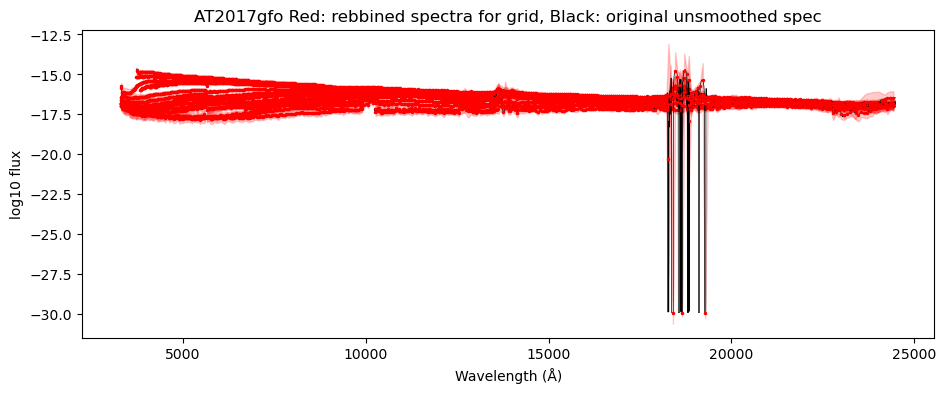

 !!!! Skipping band EFOSC2_U — no valid data.
 !!!! Skipping band GFC_r — no valid data.
 !!!! Skipping band GMOS_g — no valid data.
 !!!! Skipping band GMOS_z — no valid data.
 !!!! Skipping band IMACS_i — no valid data.
 !!!! Skipping band IMACS_r — no valid data.
 !!!! Skipping band LRIS_I — no valid data.
 !!!! Skipping band MOIRCS_Ks — no valid data.
 !!!! Skipping band SOFI_H — no valid data.
 !!!! Skipping band UVOT_B — no valid data.
 !!!! Skipping band UVOT_W2 — no valid data.


/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_96836/3467192964.py:607: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  grid_notext[key] = np.full(len(grid_notext.index), np.nan)
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_96836/3467192964.py:608: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  grid_notext_err[key] = np.full(len(grid_notext_err.index), np.nan)
/var/folders/0n/xfstb8sn23ldhmmxkvnlgk4c0000gn/T/ipykernel_96836/3467192964.py:607: PerformanceWarning: DataFrame is highly fragmented.  This is usu

Skipping band EFOSC2_U — no valid flux or flux error data.
Skipping band GFC_r — no valid flux or flux error data.
Skipping band GMOS_g — no valid flux or flux error data.
Skipping band GMOS_z — no valid flux or flux error data.
Skipping band IMACS_i — no valid flux or flux error data.
Skipping band IMACS_r — no valid flux or flux error data.
Skipping band LRIS_I — no valid flux or flux error data.
Skipping band MOIRCS_Ks — no valid flux or flux error data.
Skipping band SOFI_H — no valid flux or flux error data.
Skipping band UVOT_B — no valid flux or flux error data.
Skipping band UVOT_W2 — no valid flux or flux error data.
[GP2dim] NB6 grid_ext_columns: 8 of 321 with log10(phase days) in [-3.0, -1.0]
len(y_data_nonan) = 8789 (GP training size — primary driver of gp.compute time/OOM risk)


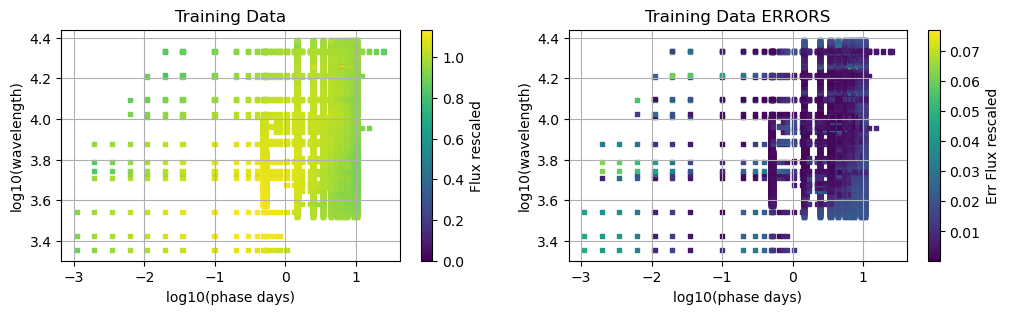

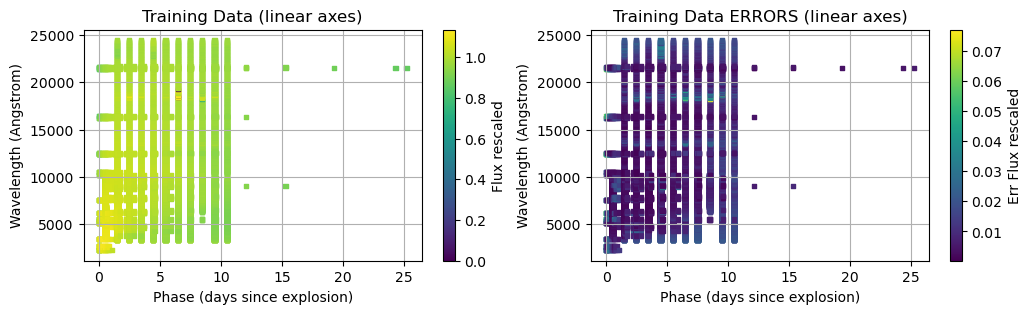

In [8]:
# try for KN:
kernel_wls_scale = 0.01
kernel_time_scale = 0.04

## Set your prior
PRIOR_file = '/prior_flat.txt'
#PRIOR_file = None

snname='AT2017gfo'
t0_fix=57982.528

## First initialize the class FullMangledSeries_Class
spec_class = FullMangledSeries_Class(snname=snname, t0_fix=t0_fix, mode='extrapolate_spectra',
                                     DELTA=30, verbose=False)
spec_class.extrapolate_log_phase_span_dex = None  # KN: never use 2 (caps ~10 d from min phase)
spec_class.gp_export_minimal = True
# Optional: training-grid diagnostics / tuning (defaults are fine for KN)
# spec_class.debug_training_grid = True  # prints linear-day extent of mjds_extention / mjds_grid
# spec_class.extrapolate_gap_fill_days = 0.1
# spec_class.extrap_phot_early_span_dex = 1.5  # log10(phase) extent for early linspace (wider => denser at early times)
# spec_class.extrap_phot_cadence_dex_late = 0.10  # lower => more late-phase LC (e.g. log10>1)
# spec_class.extrapolate_tiny_linear_gap_min_log_span_dex = 0.15  # fill sub-0.1d linear gap if log span exceeds this (GP2dim)
# spec_class.extrapolate_gap_fill_cadence_days = 0.1
# GP prediction speed (defaults in GP2dim_utils_newlog: n_wl=300, wl_step=0.01, slot_size=3)
# spec_class.gp_predict_n_wavelength = 400
# spec_class.gp_predict_wl_step = 0.01
# spec_class.gp_predict_slot_size = 6  # more phases per predict batch; fewer outer loops
# Dense GP prediction phases: evenly spaced in log10(phase days) between existing column min/max (union; default off in pipeline_config).
spec_class.gp_predict_dense_log_phase = True   # or set GP_PREDICT_DENSE_LOG_PHASE in pipeline_config.py
spec_class.gp_predict_dense_log_phase_n = 100   # np.logspace-style count along [min,max] in dex
# Load all the mangled spectra
raw_numbers, raw_numbers_err, off_xa, off_ya , grid_ext_columns = GP2dim.prepare_grid(snname, spec_class, )
GP2dim.log_prediction_phase_coverage(grid_ext_columns, label='NB6 grid_ext_columns')

# Transform for 2D GP: ln-flux (default) or affine-scaled linear flux (``pipeline_config.USE_TWO_D_GP_LINEAR_FLUX``).
import pipeline_config as _pconf
if _pconf.USE_TWO_D_GP_LINEAR_FLUX:
    y_data_nonan, y_data_nonan_err, x1_data_norm, x2_data_norm = GP2dim.transform2LINEAR_reshape(
        spec_class, raw_numbers, raw_numbers_err, off_xa, off_ya
    )
else:
    y_data_nonan, y_data_nonan_err, x1_data_norm, x2_data_norm = GP2dim.transform2LOG_reshape(
        spec_class, raw_numbers, raw_numbers_err, off_xa, off_ya
    )

print("len(y_data_nonan) =", len(y_data_nonan), "(GP training size — primary driver of gp.compute time/OOM risk)", flush=True)
# If this is very large (>~10k), try larger `DELTA` in `spec_class` to reduce wavelength rows per spectrum.

# Make some useful plots that helps to check the data you are using to interpolate the surface
# These are saved in OUTPUT_DIR/SNname/TwoDextended_spectra
GP2dim.make_plots(spec_class, y_data_nonan, y_data_nonan_err, x1_data_norm, x2_data_norm)

# Set the prior
if _pconf.USE_TWO_D_GP_LINEAR_FLUX:
    Xprior, yprior = GP2dim.setPRIOR_linear(spec_class, PRIOR_file=PRIOR_file, PRIOR_folder=PRIORs_PATH)
else:
    Xprior, yprior = GP2dim.setPRIOR(spec_class, PRIOR_file=PRIOR_file, PRIOR_folder=PRIORs_PATH)

[run_2DGP_GRID_rjf] start prior=True N_train=8789 X.shape=((8789, 2),)
[run_2DGP_GRID_rjf] ~0.58 GB dense hint / Cholesky O(N³)
[run_2DGP_GRID_rjf] dense log-phase: 321 → 419 columns
[GP2dim] phase (before merge): 8 of 321 with log10(phase days) in [-3.0, -1.0]
[GP2dim] phase (after merge): 52 of 419 with log10(phase days) in [-3.0, -1.0]
[run_2DGP_GRID_rjf] collaborator fit + predict …
[gp_utils] building LinearNDInterpolator over 472551 points (this can take ~10-30 s)
[gp_utils] cached prior interpolators to /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/twodim_ryanv2/extrapolate/diagnostics/rjf_prior_cache/prior_linear_interp.pkl
[run_2DGP_GRID_rjf] collaborator done in 103.5 s
[gp2dim_export] wrote /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/twodim_ryanv2/extrapolate/gp_minimal_export/gp_minimal_bundle.npz and /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/twodim_ryanv2/extrapolate

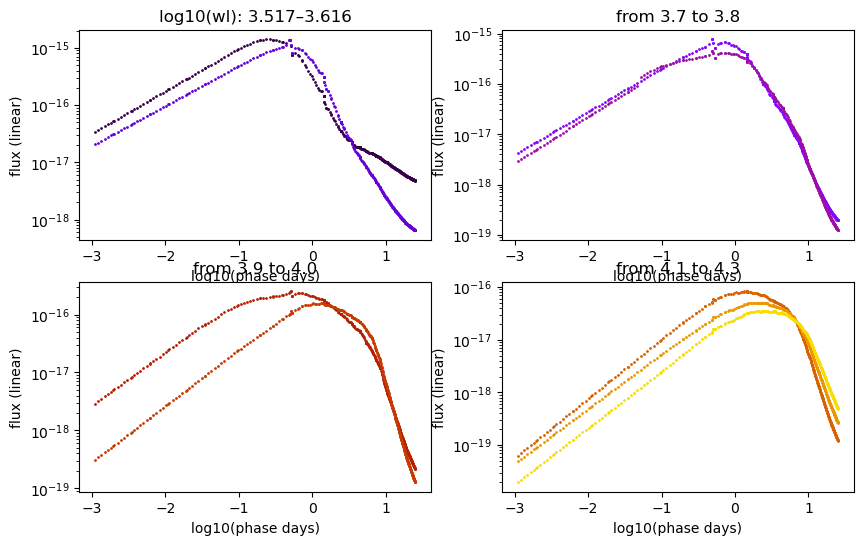

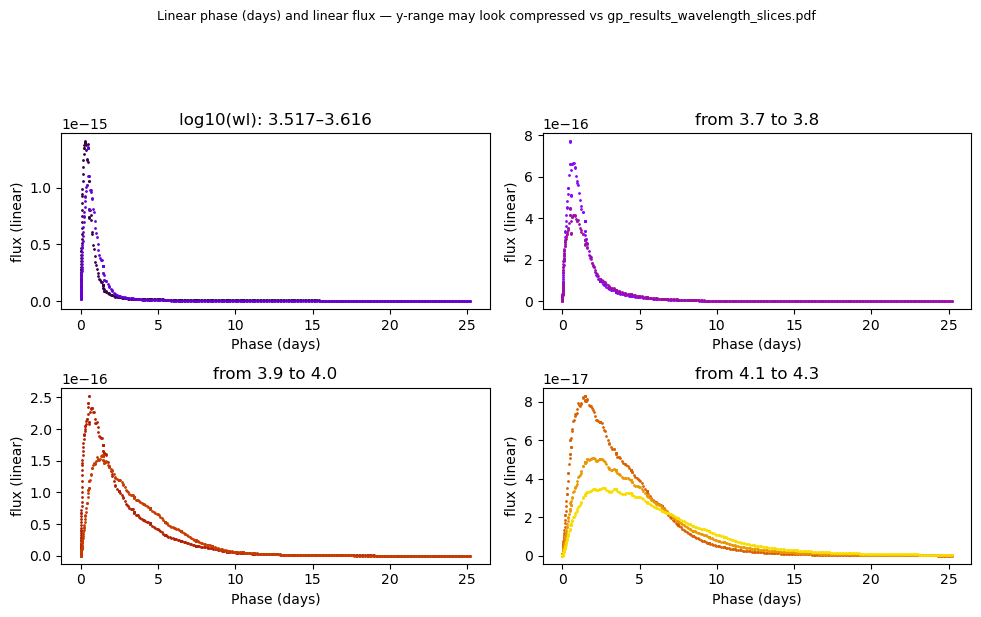

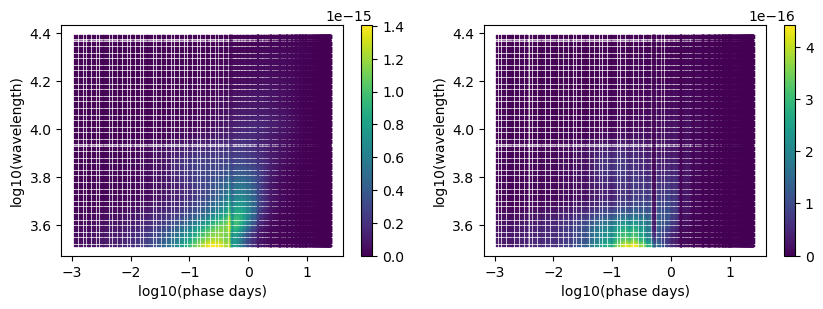

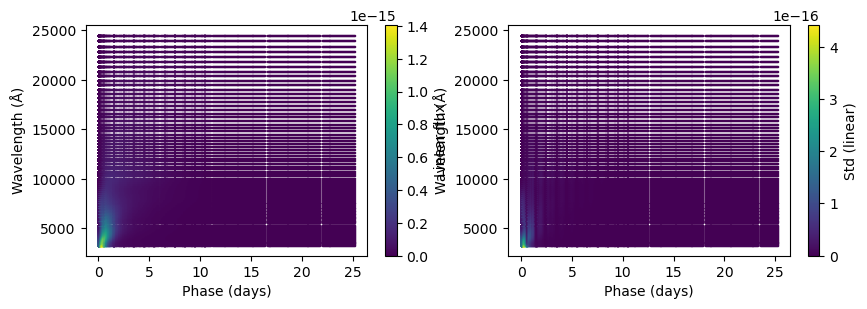

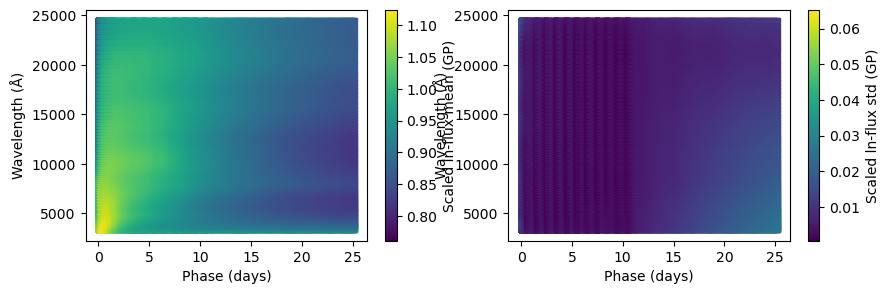

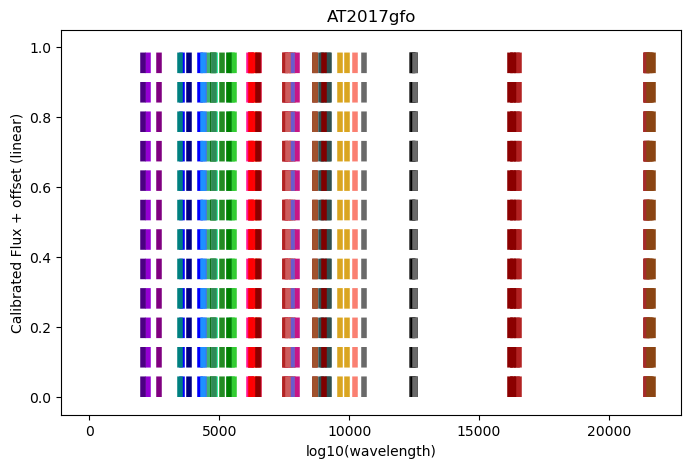

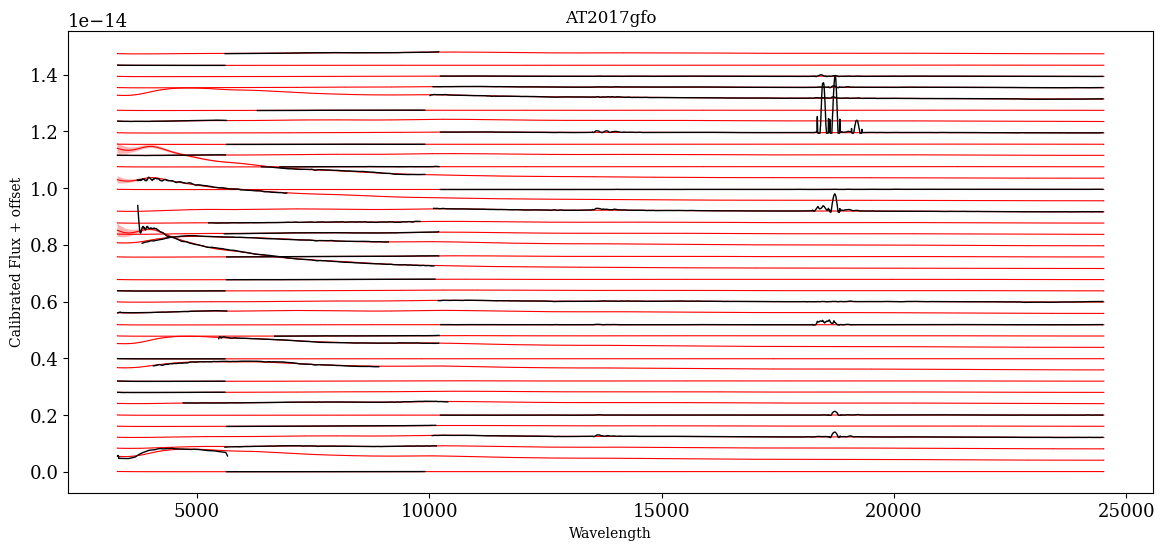

In [9]:
# Check for empty or all-NaN arrays before running GP interpolation
if (
    y_data_nonan.size == 0 or np.all(np.isnan(y_data_nonan)) or
    y_data_nonan_err.size == 0 or np.all(np.isnan(y_data_nonan_err)) or
    x1_data_norm.size == 0 or np.all(np.isnan(x1_data_norm)) or
    x2_data_norm.size == 0 or np.all(np.isnan(x2_data_norm))
):
    raise ValueError("Input data for GP interpolation contains only NaNs or is empty. Please check your data preparation steps.")

# Optional tuning on spec_class:
#   gp_diagnostic_slices=True → saves gp_diag_slot0_phase*.pdf (first batch, few phases)
#   gp_print_training_size=False → silence extra memory hints (start line still includes N_train)
#   gp_predict_progress=False → silence per-slot predict progress
#   gp_predict_log_chunks=True → per-chunk timing inside each slot (verbose)
#   spec_class.verbose=True → prior diagnostics + chunk timing

import pipeline_config as _pconf

# Do the 2dim GP interpolation (collaborator ``gp_collab_rjf``; ln-flux path only).
import GP2dim_utils_newlog_rjf as _gp_rjf
if _pconf.USE_TWO_D_GP_LINEAR_FLUX:
    raise RuntimeError(
        '6_*_rjf.ipynb: linear-flux GP is not wired here; set '
        'pipeline_config.USE_TWO_D_GP_LINEAR_FLUX=False'
    )
x1_fill, x2_fill, mu_fill, std_fill, mu_fill_raw = _gp_rjf.run_2DGP_GRID_rjf(
    spec_class,
    y_data_nonan,
    y_data_nonan_err,
    x1_data_norm,
    x2_data_norm,
    kernel_wls_scale,
    kernel_time_scale,
    grid_ext_columns,
    prior=True,
    points=Xprior,
    values=yprior,
)

# Make some useful plots that helps to check the results
# Saved under OUTPUT_DIR/SNname/TwoDextended_spectra/:
#   gp_results_wavelength_slices.pdf — log10(phase) × training-space y
#   gp_results_wavelength_slices_linear_phase_linear_flux.pdf — phase days × linear flux y
# transform_back_andPlot: 2d_surface.png = log10(phase)×log10(λ) flux map (notebook shows this first);
#   gp_2d_surface_linear_axes.pdf / .png = same flux/std on linear phase (days) × linear Å (shown inline after);
#   gp_2d_surface_linear_axes_scaled_mu.pdf = scaled training-space mean/std on linear axes (ln-flux or linear-scaled)
if _pconf.USE_TWO_D_GP_LINEAR_FLUX:
    GP2dim.make_results_plots_linear(spec_class, x1_fill, x2_fill, mu_fill, std_fill)
    mu_fill_conv, std_fill_conv, y_data_conv = GP2dim.transform_back_andPlot_linear(
        spec_class, x1_fill, x2_fill, mu_fill, std_fill, y_data_nonan
    )
else:
    GP2dim.make_results_plots(spec_class, x1_fill, x2_fill, mu_fill, std_fill)
    mu_fill_conv, std_fill_conv, y_data_conv = GP2dim.transform_back_andPlot(
        spec_class, x1_fill, x2_fill, mu_fill, std_fill, y_data_nonan
    )


### Optional — Ryan `iterate_gp_surface_bundle_scale` (surface + bundle rescaling)

After the collaborator 2-D GP cell runs, `gp_minimal_bundle.npz` (and `*_meta.json`) live under `<save_plot_path>/gp_minimal_export/`.

**Ryans prerequisite `gp_*_nophot_m8767_m8217`:** collaborator strips **whole photometric pseudo-bands** where **rounded `X[:,0]`** matches **`pipeline_config.GP_RYAN_STRIP_BANDS_ROUNDED_X1`** (default `-0.8767,-0.8217`). Set **`pipeline_config.GP_RYAN_STRIP_PHOT_BANDS_BEFORE_ITERATE=True`** or **`RUN_RYAN_STRIP_BAD_PHOT_BANDS=True`** in the code cell below to mirror that (writes `gp_minimal_bundle_nophot_m8767_m8217.npz` and feeds iterate from it). Omitting strip leaves problematic phot LC rows in training (see **RYAN_GP_V2_INTEGRATION.md**, parity subsection).

Iterate flags now follow **`RUNNING_MY_SURFACE_ITER.md`** via **`pipeline_config`**: **`--optimize`** (`GP_RYAN_ITERATE_OPTIMIZE_RUN_GP`), **`--surface-mu-key`** (**`GP_RYAN_ITERATE_SURFACE_MU_KEY`**, default `mu_raw`), convergence + `--run-gp-max-iter` + **`--bundle-scale-clip`**. Set **`GP_RYAN_WRITE_GP_STYLE_CHECKS=True`** to dump headless collaborator **`plot_results`** / **`plot_bands_gp_overview`** PNGs under `ryan_surface_iterations/<GP_RYAN_GP_STYLE_CHECKS_SUBDIR>/`.

The vendored driver `Codes/ryan_gp/iterate_gp_surface_bundle_scale.py` subprocess-calls `run_gp.py` repeatedly, rescaling spectroscopic bundles vs the GP surface (`spec_bundle_id` / `train_obs_class` keys must be present).

Skip this cell unless you need that loop. Set **`RUN_RYAN_ITERATE_GP_SURFACE=True`**; tune **`RYAN_GP_TAG_PREFIX`**, **`RYAN_ITER_MAX_ITERS`**.


In [ ]:
# Ryan iterative GP surface + bundle scale (optional; see markdown above).
RUN_RYAN_ITERATE_GP_SURFACE = True
# Parity with Ryans ``gp_*_nophot_m8767_m8217``: strip photometry at rounded X[:,0] in ``GP_RYAN_STRIP_BANDS_ROUNDED_X1`` (``pipeline_config``, or override here).
RUN_RYAN_STRIP_BAD_PHOT_BANDS = None  # None => use ``pipeline_config.GP_RYAN_STRIP_PHOT_BANDS_BEFORE_ITERATE``
RYAN_GP_TAG_PREFIX = "coco_ryan_surface"
RYAN_ITER_MAX_ITERS = 5
if RUN_RYAN_ITERATE_GP_SURFACE:
    import os
    import subprocess
    import sys

    import pipeline_config as _rpc

    _codes = os.path.join(os.path.normpath(_rpc.COCO_PATH.rstrip("/\\" + os.sep)), "Codes")
    if _codes not in sys.path:
        sys.path.insert(0, _codes)

    _strip = bool(RUN_RYAN_STRIP_BAD_PHOT_BANDS if RUN_RYAN_STRIP_BAD_PHOT_BANDS is not None else _rpc.GP_RYAN_STRIP_PHOT_BANDS_BEFORE_ITERATE)

    _repo = os.path.normpath(_rpc.COCO_PATH.rstrip("/\\" + os.sep))
    _ryan = os.path.join(_repo, "Codes", "ryan_gp")
    _export = os.path.join(spec_class.save_plot_path, _rpc.GP_EXPORT_SUBDIR)
    _bundle = os.path.join(_export, "gp_minimal_bundle.npz")
    _meta = os.path.splitext(_bundle)[0] + "_meta.json"
    _workspace = os.path.join(spec_class.save_plot_path, "ryan_surface_iterations")
    _runs_dir = os.path.join(spec_class.save_plot_path, "ryan_gp_runs")
    for d in (_export, _workspace, _runs_dir):
        os.makedirs(d, exist_ok=True)

    _bundle_iterate = _bundle
    if _strip:
        import ryan_v2_iterate_prep as _rvprep

        _bundle_iterate = _rvprep.strip_minimal_export_bundle(
            _export,
            out_name=_rpc.GP_RYAN_STRIP_OUTPUT_NPZ,
            bands_csv=_rpc.GP_RYAN_STRIP_BANDS_ROUNDED_X1,
            round_digits=4,
            phot_spec_threshold=_rpc.GP_EXPORT_PHOT_SPEC_THRESHOLD,
            ryan_gp_dir=_ryan,
            python_exe=sys.executable,
        )
        print("[ryan_v2] stripped phot bands → iterate --input-bundle=%s" % _bundle_iterate)

    _run_gp_tail = [
        "--additive-time",
        "--additive-wls",
        "--kernel-time",
        "matern52",
        "--kernel-wls",
        "matern52",
        "--mean",
        "linear",
        "--meta-json",
        _meta,
    ]
    if bool(_rpc.GP_RYAN_ITERATE_OPTIMIZE_RUN_GP):
        _run_gp_tail.append("--optimize")

    cmd = [
        sys.executable,
        os.path.join(_ryan, "iterate_gp_surface_bundle_scale.py"),
        "--input-bundle",
        _bundle_iterate,
        "--meta",
        _meta,
        "--workspace",
        _workspace,
        "--runs-dir",
        _runs_dir,
        "--gp-tag-prefix",
        RYAN_GP_TAG_PREFIX,
        "--max-iters",
        str(int(RYAN_ITER_MAX_ITERS)),
        "--surface-mu-key",
        str(_rpc.GP_RYAN_ITERATE_SURFACE_MU_KEY),
        "--bundle-scale-clip",
        str(float(_rpc.GP_RYAN_ITERATE_BUNDLE_SCALE_CLIP)),
        "--converge-max-log-scale",
        str(float(_rpc.GP_RYAN_ITERATE_CONVERGE_MAX_LOG_SCALE)),
        "--converge-delta-chi2-spec",
        str(float(_rpc.GP_RYAN_ITERATE_CONVERGE_DELTA_CHI2_SPEC)),
        "--run-gp-max-iter",
        str(int(_rpc.GP_RYAN_ITERATE_RUN_GP_MAX_ITER)),
        "--",
    ] + _run_gp_tail

    print("[ryan_v2] cwd=%s" % _ryan)
    print("[ryan_v2] " + " ".join(cmd))
    subprocess.check_call(cmd, cwd=_ryan)

    if bool(_rpc.GP_RYAN_WRITE_GP_STYLE_CHECKS):
        import ryan_v2_finalize_iter_surface as _rvfi
        import ryan_v2_gp_style_checks as _rvplot

        _k = _rvfi.resolve_last_iteration_index(_workspace)
        if _k is None:
            print("[ryan_v2] GP style checks skipped (no iteration index in %s)" % _workspace)
        else:
            _tag_done, _out = _rvplot.run_gp_style_check_pngs(
                workspace=_workspace,
                runs_dir=_runs_dir,
                meta=_meta,
                gp_tag_prefix=RYAN_GP_TAG_PREFIX,
                k_final=int(_k),
                ryan_gp_dir=_ryan,
                bands_overview_only=str(_rpc.GP_RYAN_GP_STYLE_CHECKS_BANDS_IDS),
                python_exe=sys.executable,
                out_subdir_under_workspace=_rpc.GP_RYAN_GP_STYLE_CHECKS_SUBDIR,
            )
            print("[ryan_v2] wrote collaborator-style PNGs tag=%s overlay_dir=%s/plot_bands_overview" % (_tag_done, _out))
else:
    print("[ryan_v2] iterate_gp_surface_bundle_scale skipped (RUN_RYAN_ITERATE_GP_SURFACE=False)")


In [ ]:
# George hyperparameter viewer (classic ``run_2DGP_GRID`` only).
# Collaborator GP: see ``diagnostics/rjf_gp_config.json`` after the fit.


In [ ]:
import pipeline_config as _pconf
if _pconf.USE_TWO_D_GP_LINEAR_FLUX:
    import GP2dim_utils_newlog_linear_flux as GP2dim
elif getattr(_pconf, "USE_TWO_D_GP_ZSCORE_COORDS", False):
    import GP2dim_utils_newlog_zscore as GP2dim
else:
    import GP2dim_utils_newlog as GP2dim

if _pconf.USE_TWO_D_GP_LINEAR_FLUX:
    GP2dim.make_results_plots_linear(spec_class, x1_fill, x2_fill, mu_fill, std_fill)
    mu_fill_conv, std_fill_conv, y_data_conv = GP2dim.transform_back_andPlot_linear(
        spec_class, x1_fill, x2_fill, mu_fill, std_fill, y_data_nonan
    )
else:
    GP2dim.make_results_plots(spec_class, x1_fill, x2_fill, mu_fill, std_fill)
    mu_fill_conv, std_fill_conv, y_data_conv = GP2dim.transform_back_andPlot(
        spec_class, x1_fill, x2_fill, mu_fill, std_fill, y_data_nonan
    )

In [ ]:
GP2dim.save_plots_files(spec_class, grid_ext_columns, y_data_conv, x1_fill, x2_fill, 
                        mu_fill_conv, std_fill_conv)
spec_class.mode = 'extend_spectra'
GP2dim.save_plots_files(spec_class, grid_ext_columns, y_data_conv, x1_fill, x2_fill, 
                                mu_fill_conv, std_fill_conv)

### Vendor iterate bridge (`ryan-updates/` …) → notebook 7

Use this when you have a **completed collaborator surface-iteration tree** (Ryan or your own) outside `Outputs/`, and want **notebook 6** to run **`transform_back_andPlot` + `save_plots_files`** using that run’s **`predictions.npz`** so **notebook 7** sees the iterated GP fill.

**Layout** (same as `iterate_gp_surface_bundle_scale`): a directory containing **`iteration_log.jsonl`** and **`iter_<KK>/predictions.npz`** — e.g. `ryan-updates/my_surface_iter_repro_bundle/runs/my_surface_iter/` (the repo may omit large **`.npz`** files; copy Ryan’s full **`predictions.npz`** drops there or point the path anywhere on disk).

In the **finalize** code cell below:

- Set **`RYAN_VENDOR_SURFACE_WORKSPACE`** to that directory (absolute path recommended).
- Set **`RUN_FINALIZE_RYAN_ITER_SURFACE=True`** after you have **`run_2DGP_GRID`** artifacts in-session **`grid_ext_columns`**, **`y_data_nonan`**, **`spec_class`**).

**Scientific prerequisite:** **`X_fill`** inside the vendor **`predictions.npz`** must match the prediction grid for **this** notebook run (same **`gp_minimal_bundle`** training / extrapolation phases). Enable **`VERIFY_VENDOR_X_FILL`** (default) so the cell compares predictions to **`<save_plot_path>/<GP_EXPORT_SUBDIR>/gp_minimal_bundle.npz`**. Turn off **`VERIFY_VENDOR_X_FILL`** only if you accept inconsistent downstream spectra.

Notebook **7** (Ryan v2): keep **`REMANGLE_IDENTITY_ONLY = True`** and **0** refinement iterations when you only need NB7 bookkeeping on the finalized extended spectra.


### Optional — Finalize iterated Ryan GP for notebook 7

**Vendor / out-of-tree workspace:** See the markdown cell above — set `RYAN_VENDOR_SURFACE_WORKSPACE` in the finalize code cell instead of iterating under `save_plot_path/ryan_surface_iterations/`.

Runs **after** the `iterate_gp_surface_bundle_scale` cell (with `RUN_RYAN_ITERATE_GP_SURFACE=True` and a finished `ryan_surface_iterations/` tree), **or** after dropping vendor `predictions.npz`.

Set `RUN_FINALIZE_RYAN_ITER_SURFACE=True` in the following code cell to load **`iter_KK/predictions.npz`** from **`spec_class.save_plot_path/ryan_surface_iterations/`**, then run **`transform_back_andPlot`** / **`save_plots_files`**. Use **`FINAL_SURFACE_MU_KEY=None`** to follow **`pipeline_config.GP_RYAN_ITERATE_SURFACE_MU_KEY`** (same latent channel iterate uses for **`--surface-mu-key`**) or override (**`"mu"`** = post mono/blue collaborator surface).

Copy your `save_plot_path` tree first if you want to keep a side-by-side of collaborator vs iterated fills.

Notebook **7**: keep **`REMANGLE_IDENTITY_ONLY = True`** and **0 refinement iterations** for identity bookkeeping without flux warp.


[ryan_v2_finalize] iter_19 [surf_iter_k19] loaded mu_raw / std (N_fill=37291) workspace=/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/ryan-updates/my_surface_iter_repro_bundle/runs/my_surface_iter
[ryan_v2_finalize] OK: predictions X_fill matches gp_minimal_bundle X_fill


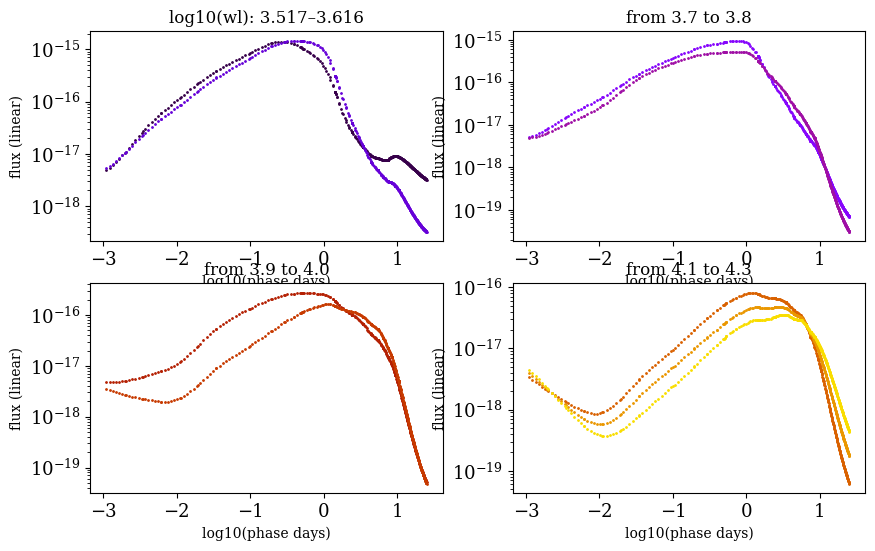

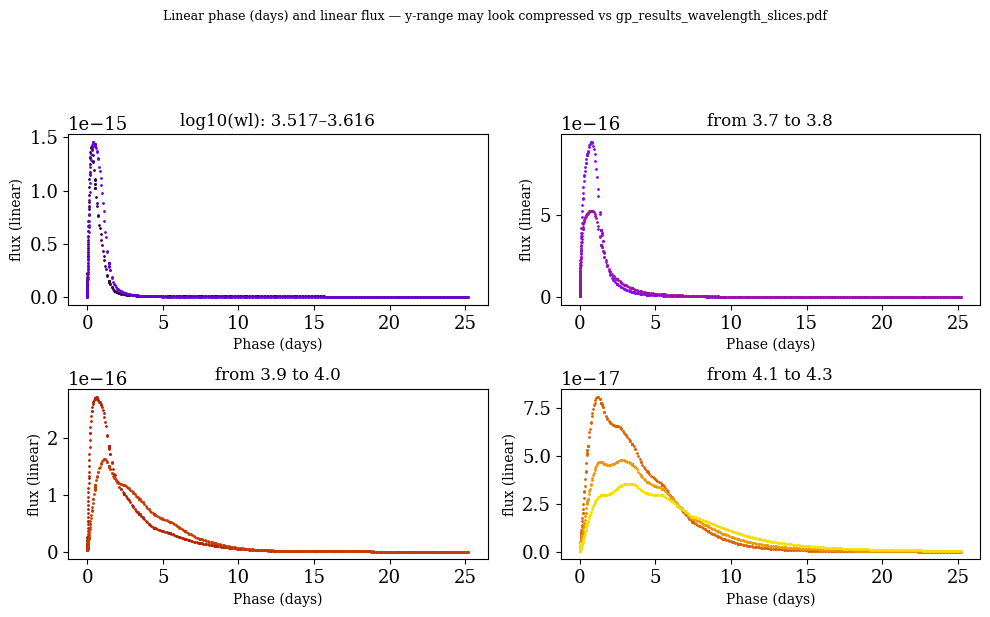

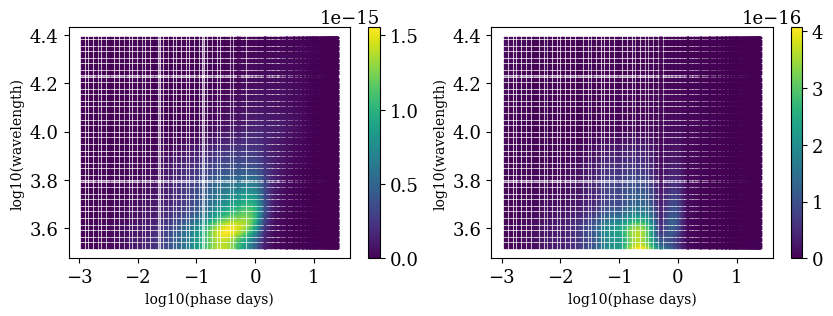

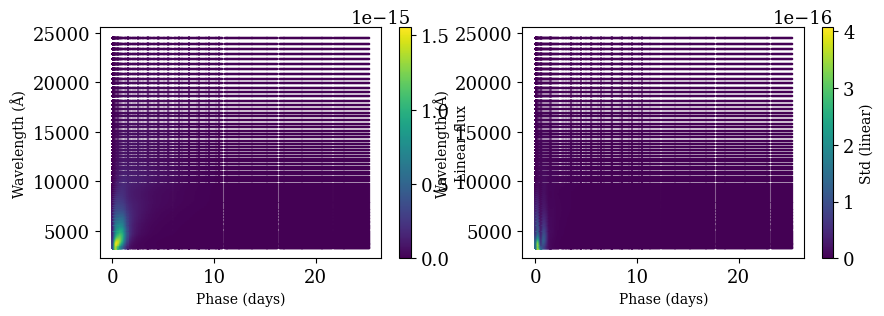

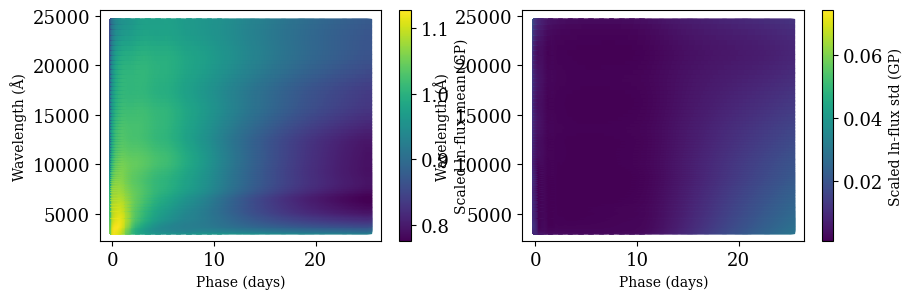

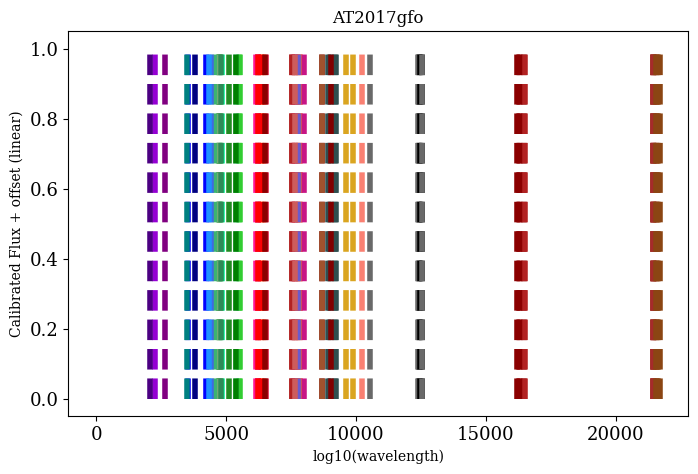

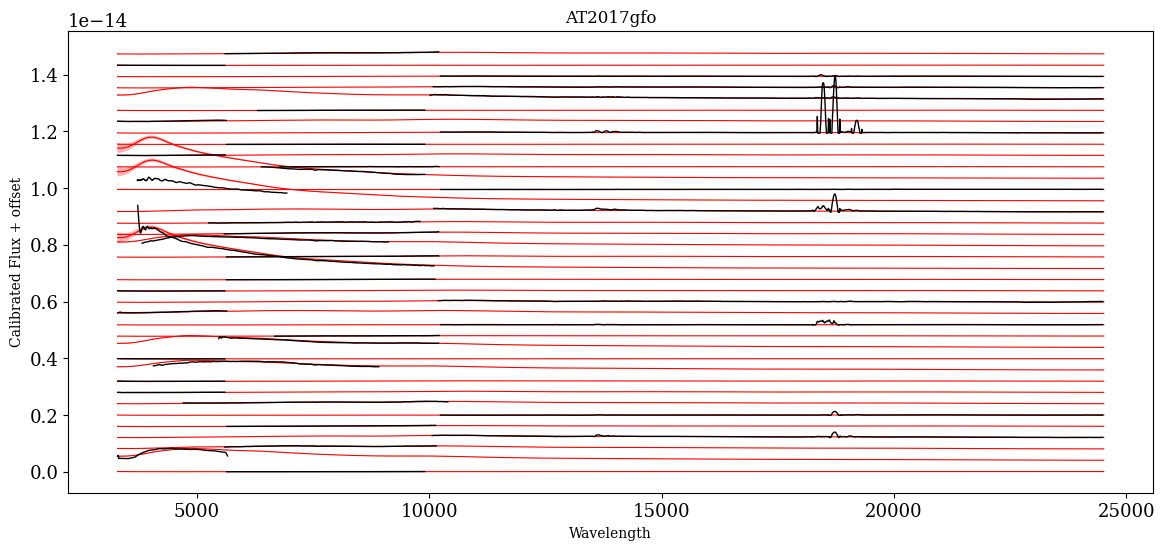

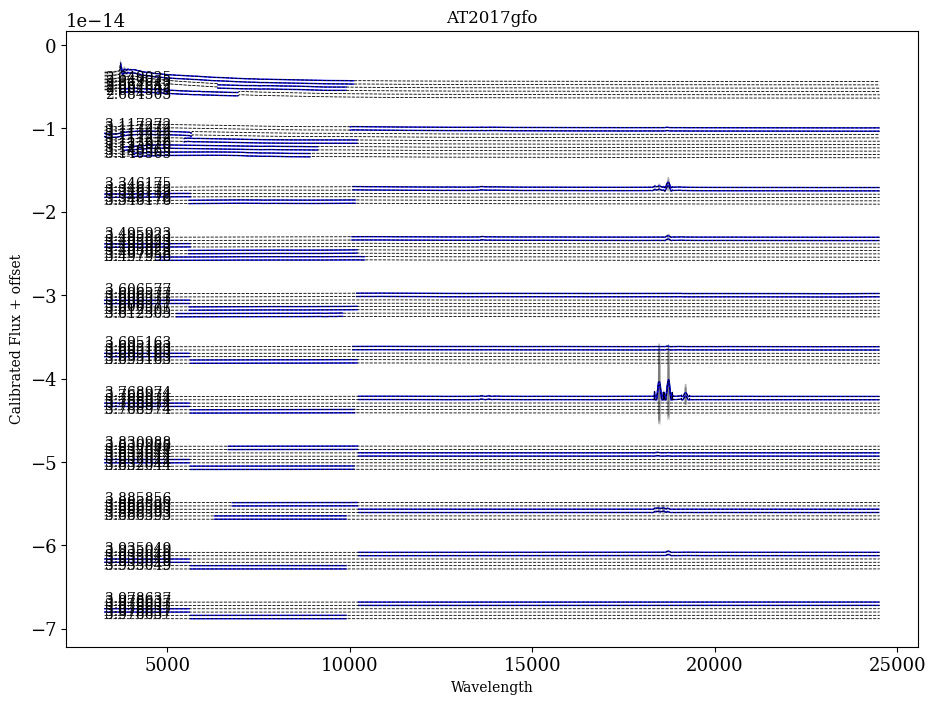

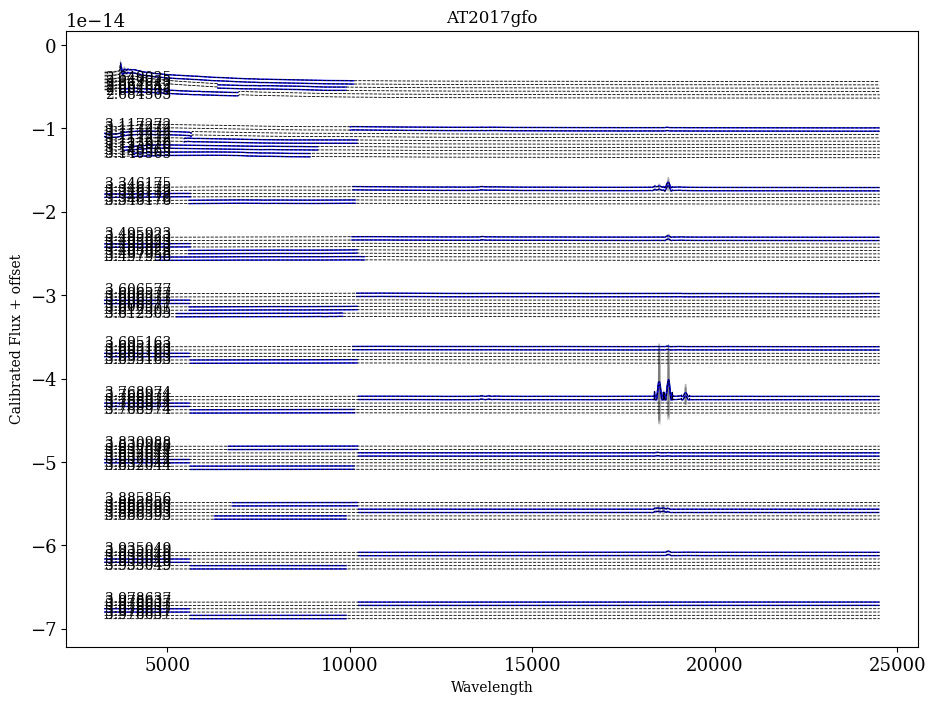

[ryan_v2_finalize] overwrote NB7-ingest spectra under /Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/twodim_ryanv2/extrapolate


In [11]:
# Plot + save_gp extended files from LAST collaborator iterate (paths → notebook 7).
RUN_FINALIZE_RYAN_ITER_SURFACE = True  # True when vendor tree or ``ryan_surface_iterations/`` has ``predictions.npz``

# Vendor bridge (optional): directory with ``iteration_log.jsonl`` + ``iter_<KK>/predictions.npz``.
# After ``_repo_root`` is defined you can set ``RYAN_VENDOR_SURFACE_WORKSPACE``, e.g.
# ``os.path.join(_repo_root, "ryan-updates/my_surface_iter_repro_bundle/runs/my_surface_iter")``.
import os
import sys
import numpy as np
import pipeline_config as _pconf

_repo_root = os.path.normpath(_pconf.COCO_PATH.rstrip("/\\" + os.sep))
_codes = os.path.join(_repo_root, "Codes")
if _codes not in sys.path:
	sys.path.insert(0, _codes)

RYAN_VENDOR_SURFACE_WORKSPACE = os.path.join(_repo_root, "ryan-updates/my_surface_iter_repro_bundle/runs/my_surface_iter")
RYAN_VENDOR_FORCE_ITER_K = 19  # None = last iter from log / highest ``iter_*`` dir; else e.g. 19

FINAL_SURFACE_MU_KEY = None  # None → ``pipeline_config.GP_RYAN_ITERATE_SURFACE_MU_KEY``
FINAL_SURFACE_STD_KEY = None  # None → ``std`` (override if vendor preds use another key)

VERIFY_VENDOR_X_FILL = True  # compare loaded ``X_fill`` to ``gp_minimal_bundle.npz`` when present

import ryan_v2_finalize_iter_surface as _rvfi

_workspace = getattr(spec_class, "ryan_surface_workspace", None)
if _workspace is None:
	_workspace = _rvfi.default_ryan_surface_workspace(spec_class.save_plot_path)

if RYAN_VENDOR_SURFACE_WORKSPACE:
	spec_class.ryan_surface_workspace = os.path.abspath(
		os.path.expanduser(str(RYAN_VENDOR_SURFACE_WORKSPACE))
	)
	_workspace = spec_class.ryan_surface_workspace

_mu_key = FINAL_SURFACE_MU_KEY if FINAL_SURFACE_MU_KEY is not None else str(
	_pconf.GP_RYAN_ITERATE_SURFACE_MU_KEY
)
_std_key = FINAL_SURFACE_STD_KEY if FINAL_SURFACE_STD_KEY is not None else "std"
_force_iter = int(RYAN_VENDOR_FORCE_ITER_K) if RYAN_VENDOR_FORCE_ITER_K is not None else None

if RUN_FINALIZE_RYAN_ITER_SURFACE:
	try:
		_k_iter, x1_fill, x2_fill, mu_fill, std_fill, _log_rec = _rvfi.load_final_surface_arrays(
			_workspace,
			mu_key=_mu_key,
			std_key=_std_key,
			iteration=_force_iter,
		)
	except (FileNotFoundError, KeyError, ValueError) as exc:
		print("[ryan_v2_finalize] aborted: %s" % exc)
		raise
	_tag = ""
	if _log_rec and isinstance(_log_rec.get("gp_tag"), str):
		_tag = " [%s]" % _log_rec["gp_tag"]
	print(
		"[ryan_v2_finalize] iter_%02i%s loaded %s / %s (N_fill=%i) workspace=%s"
		% (_k_iter, _tag, _mu_key, _std_key, x1_fill.size, _workspace)
	)

	if VERIFY_VENDOR_X_FILL:
		_bdir = os.path.join(
			os.path.normpath(spec_class.save_plot_path), _pconf.GP_EXPORT_SUBDIR
		)
		_bnp = os.path.join(_bdir, "gp_minimal_bundle.npz")
		if os.path.isfile(_bnp):
			zb = np.load(_bnp, allow_pickle=False)
			try:
				if "X_fill" in zb.files:
					X_ref = np.asarray(zb["X_fill"], dtype=np.float64)
					X_vendor = np.column_stack(
						[np.asarray(x1_fill, dtype=np.float64), np.asarray(x2_fill, dtype=np.float64)]
					)
					if (
						X_ref.shape != X_vendor.shape
						or not np.allclose(X_ref, X_vendor, rtol=1e-12, atol=1e-12, equal_nan=True)
					):
						raise ValueError(
							"[ryan_v2_finalize] X_fill mismatch vs %s (shape %s vs %s). "
							"Vendor iterate must share the same GP prediction grid as this export."
							% (_bnp, X_ref.shape, X_vendor.shape)
						)
					print(
						"[ryan_v2_finalize] OK: predictions X_fill matches gp_minimal_bundle X_fill"
					)
				else:
					print("[ryan_v2_finalize] WARN: %s has no X_fill — skip parity check" % _bnp)
			finally:
				zb.close()
		else:
			print("[ryan_v2_finalize] WARN: no %s — skip X_fill parity check" % _bnp)

	if _pconf.USE_TWO_D_GP_LINEAR_FLUX:
		import GP2dim_utils_newlog_linear_flux as GP2dim

		GP2dim.make_results_plots_linear(spec_class, x1_fill, x2_fill, mu_fill, std_fill)
		mu_fill_conv, std_fill_conv, y_data_conv = GP2dim.transform_back_andPlot_linear(
			spec_class, x1_fill, x2_fill, mu_fill, std_fill, y_data_nonan
		)
	else:
		if getattr(_pconf, "USE_TWO_D_GP_ZSCORE_COORDS", False):
			import GP2dim_utils_newlog_zscore as GP2dim
		else:
			import GP2dim_utils_newlog as GP2dim

		GP2dim.make_results_plots(spec_class, x1_fill, x2_fill, mu_fill, std_fill)
		mu_fill_conv, std_fill_conv, y_data_conv = GP2dim.transform_back_andPlot(
			spec_class, x1_fill, x2_fill, mu_fill, std_fill, y_data_nonan
		)

	GP2dim.save_plots_files(
		spec_class, grid_ext_columns, y_data_conv, x1_fill, x2_fill, mu_fill_conv, std_fill_conv
	)
	spec_class.mode = "extend_spectra"
	GP2dim.save_plots_files(
		spec_class, grid_ext_columns, y_data_conv, x1_fill, x2_fill, mu_fill_conv, std_fill_conv
	)
	print(
		"[ryan_v2_finalize] overwrote NB7-ingest spectra under %s"
		% spec_class.save_plot_path
	)
else:
	print("[ryan_v2_finalize] skipped (RUN_FINALIZE_RYAN_ITER_SURFACE=False)")
